In [23]:
## aart_func is a file with the functions for the image generation
from aart_func import *
## params have all the important params of the simulation
from params import *
plt.rcParams['text.usetex'] = True


Thanks for using AART
Copyright (C) 2023, A. Cardenas-Avendano, H. Zhu & A. Lupsasca



In [3]:
# local paths for loading data and downloading images
path_lensingband17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5"
path_lensingband60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5"

path_raytracing17 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5"
path_raytracing60 = r"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5"

path_images = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes"

In [5]:
import numpy as np

def freedman_diaconis_bins(data):
    """
    Calculates the optimal number of bins using the Freedman-Diaconis rule.
    Ideal for approximately normal distributions with anomalies.
    
    Parameters:
    -----------
    data : array-like
        Input data array
        
    Returns:
    --------
    n_bins : int
        Optimal number of bins for histogram
    """
    data = np.asarray(data)
    n = len(data)
    
    # Data range
    data_range = data.max() - data.min()
    
    # Interquartile range (robust to outliers)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    
    # Avoid division by zero
    if IQR == 0:
        IQR = data_range / 10  # fallback
    
    # Bin width according to Freedman-Diaconis
    bin_width = 2 * IQR * n ** (-1/3)
    
    # Number of bins
    n_bins = max(1, int(np.ceil(data_range / bin_width)))
    
    # Upper limit to avoid excessive bins
    n_bins = min(n_bins, 500)
    
    return n_bins

# Histogram for $n=0$, with $ \theta_o = 17^\circ$ and  $ \theta_o = 60^\circ$

In [4]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N17_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [7]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


In [11]:
#time renormalizartion 
t_renorm_17 = t0 + (D_obs + 2*np.log(D_obs))
alpha17 = supergrid0[:, 0]
beta17 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_17)
alpha17 = alpha17[valid_mask]
beta17 = beta17[valid_mask]
t_renorm_17 = t_renorm_17[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin17, Tmax17 = np.percentile(t_renorm_17, [minV,maxV])
Bins17 =  freedman_diaconis_bins(t_renorm_17)
print("original range of coordinates",np.min(t_renorm_17),np.max(t_renorm_17))
print("filtered range of coordinates",Tmin17,Tmax17)

# Create a mask for the values within the range 
mask_in_range_17 = (t_renorm_17 >= Tmin17) & (t_renorm_17 <= Tmax17 )

#data filtering 
t_renorm_17 = t_renorm_17[mask_in_range_17]
alpha17 = alpha17[mask_in_range_17]
beta17 = beta17[mask_in_range_17]

original range of coordinates -35.667235246168275 14.249619164365868
filtered range of coordinates -35.667235246168275 14.138239200566256


In [13]:
# Lensing bands params importation for i = 60
fnbands = path_lensingband60
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N60_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])


h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5


In [15]:
# Ray tracing params importation for i = 60
fnrays = path_raytracing60
#Imprimimos la dirección donde se encuentran
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5


In [17]:
#time renormalizartion 
t_renorm_60 = t0 + (D_obs + 2*np.log(D_obs))
alpha60 = supergrid0[:, 0]
beta60 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_60)
alpha60 = alpha60[valid_mask]
beta60 = beta60[valid_mask]
t_renorm_60 = t_renorm_60[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin60, Tmax60 = np.percentile(t_renorm_60, [minV,maxV])
Bins60 =  freedman_diaconis_bins(t_renorm_60)
print("original range of coordinates",np.min(t_renorm_60),np.max(t_renorm_60))
print("filtered range of coordinates",Tmin60,Tmax60)

# Create a mask for the values within the range 
mask_in_range_60 = (t_renorm_60 >= Tmin60) & (t_renorm_60 <= Tmax60 )

#data filtering 
t_renorm_60 = t_renorm_60[mask_in_range_60]
alpha60 = alpha60[mask_in_range_60]
beta60 = beta60[mask_in_range_60]

original range of coordinates -34.796777076264334 50.90384215697486
filtered range of coordinates -34.796777076264334 50.83806008011077


In [32]:
Bins = int((Bins17 + Bins60)/2)

In this case, the histogram has been normalized so that the distribution has the same area. This is made with  `plt.hist(density=True)` 

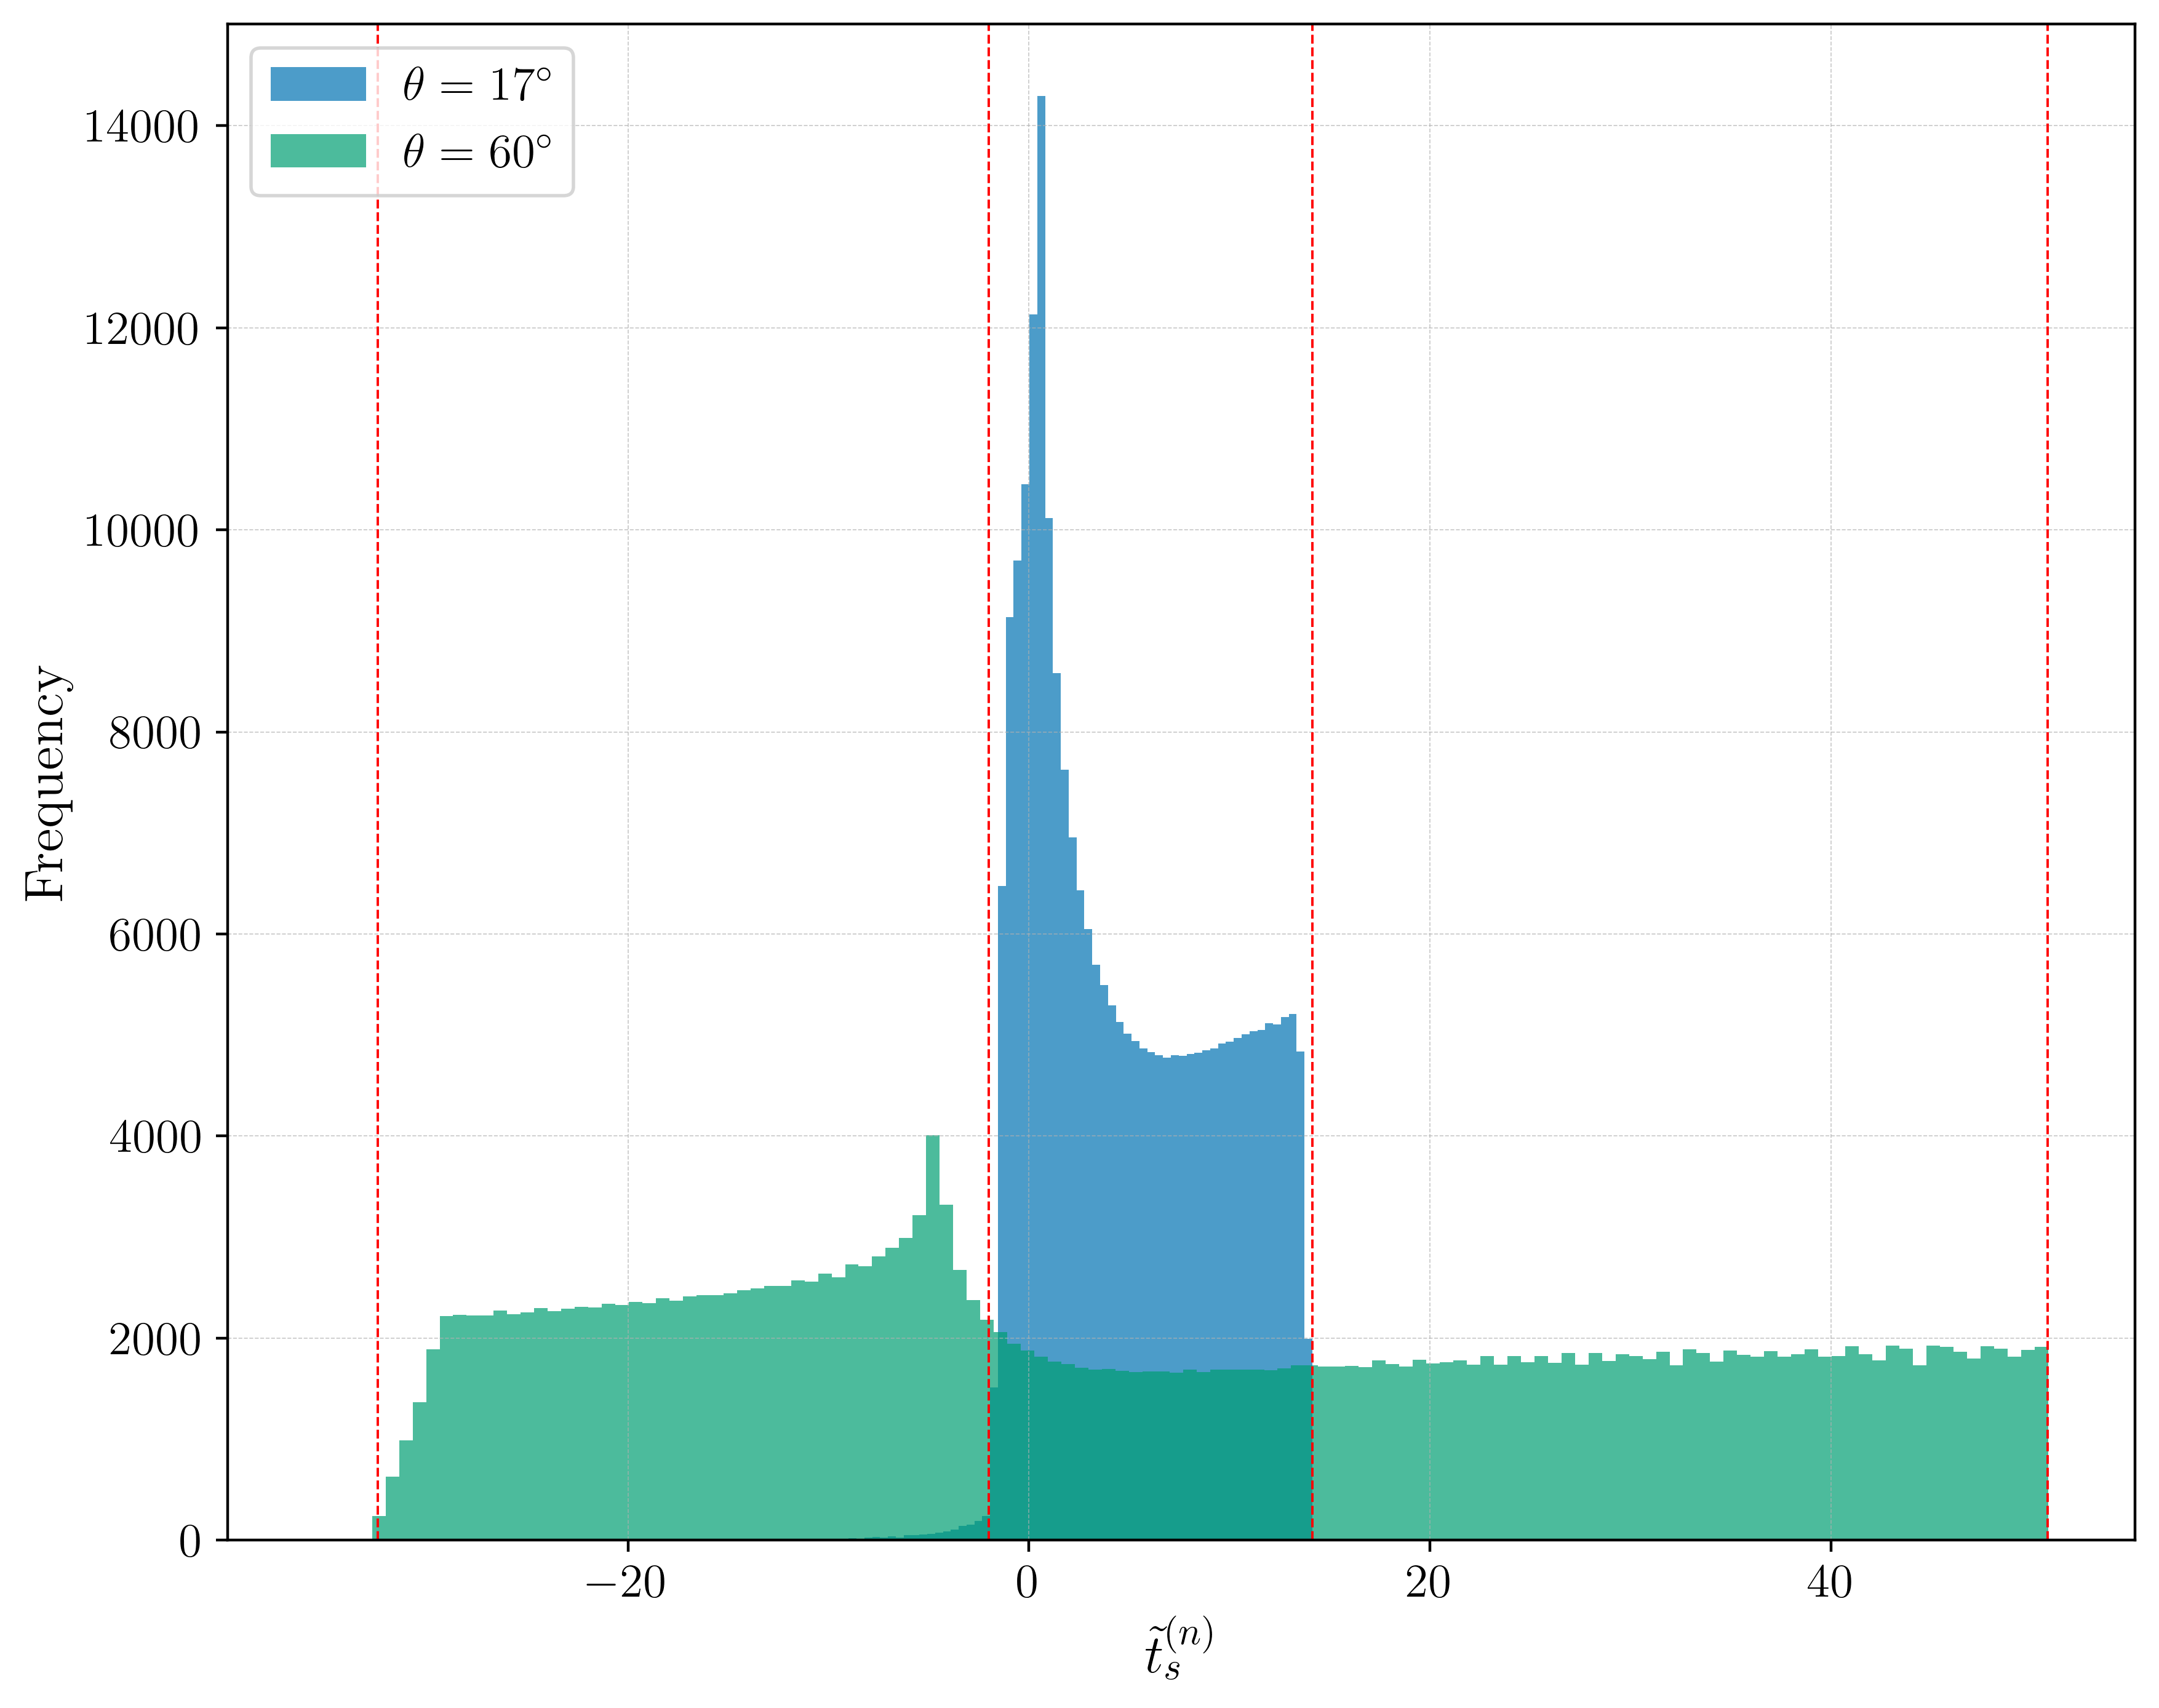

In [34]:
import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)

#peso_17 = np.ones_like(t_renorm_17) / N17_live0
#peso_60 = np.ones_like(t_renorm_60) / N60_live0

plt.hist(t_renorm_17, bins=Bins, color='#0072B2', label=r"$\theta = 17^{\circ}$", density=False, alpha=0.7)
plt.axvline(x=-32.5, color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=50.83, color='red', linestyle='--', linewidth=0.7)

plt.hist(t_renorm_60, bins=Bins, color='#009E73', label=r"$\theta = 60^{\circ}$", density=False, alpha=0.7)
plt.axvline(x=-2, color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=14.13, color='red', linestyle='--', linewidth=0.7)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

#plt.savefig(path_images + rf"\HistoGrama_origi_total.png",dpi=400,bbox_inches='tight')

plt.show()


# Histogram of $n=0,1,2$ lensing bands with  $ \theta_o = 17^\circ$

In [8]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
lim0=int(h5f["lim0"][0])

supergrid1=h5f['grid1'][:]
N1=int(h5f["N1"][0])
mask1=h5f['mask1'][:]
lim1=int(h5f["lim1"][0])

supergrid2=h5f['grid2'][:]
N2=int(h5f["N2"][0])
mask2=h5f['mask2'][:]
lim2=int(h5f["lim2"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [10]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

rs1=h5f['rs1'][:]
sign1=h5f['sign1'][:]
t1=h5f['t1'][:]
phi1=h5f['phi1'][:]

rs2=h5f['rs2'][:]
sign2=h5f['sign2'][:]
t2=h5f['t2'][:]
phi2=h5f['phi2'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


## $n=0$

In [12]:
#time renormalizartion 
t_renorm_0 = t0 #+ (D_obs + 2*np.log(D_obs))
alpha0 = supergrid0[:, 0]
beta0 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_0)
alpha0 = alpha0[valid_mask]
beta0 = beta0[valid_mask]
t_renorm_0 = t_renorm_0[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin0, Tmax0 = np.percentile(t_renorm_0, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_0),np.max(t_renorm_0))
print("filtered range of coordinates",Tmin0,Tmax0)

# Create a mask for the values within the range 
mask_in_range_0 = (t_renorm_0 >= Tmin0) & (t_renorm_0 <= Tmax0 )

#data filtering 
t_renorm_0 = t_renorm_0[mask_in_range_0]
alpha0 = alpha0[mask_in_range_0]
beta0 = beta0[mask_in_range_0]

# Calculate the number of bins using the Freedman-Diaconis rule
Q1 = np.percentile(t_renorm_0, 25)
Q3 = np.percentile(t_renorm_0, 75)
IQR = Q3 - Q1
rango = np.max(t_renorm_0) - np.min(t_renorm_0)

# Calcular el número de bins usando la regla de Freedman-Diaconis
N = len(t_renorm_0)
bins_freedman_diaconis0 = int(np.ceil(rango / (2 * IQR) * N**(1/3)))
bins_freedman_diaconis0
print("bins of the histogram:",bins_freedman_diaconis0)

original range of coordinates -10054.087915990121 -10004.171061579587
filtered range of coordinates -10054.087915990121 -10004.282441543386
bins of the histogram: 188


## $n=1$

In [14]:
#time renormalizartion 
t_renorm_1 = t1 #+ (D_obs + 2*np.log(D_obs))
alpha1 = supergrid1[:, 0]
beta1 = supergrid1[:, 1]

valid_mask = np.isfinite(t_renorm_1)
alpha1 = alpha1[valid_mask]
beta1 = beta1[valid_mask]
t_renorm_1 = t_renorm_1[valid_mask]

#data filtering by percentiles
minV = 5
maxV = 99.95
Tmin1, Tmax1 = np.percentile(t_renorm_1, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_1),np.max(t_renorm_1))
print("filtered range of coordinates",Tmin1,Tmax1)

# Create a mask for the values within the range 
mask_in_range_1 = (t_renorm_1 >= Tmin1) & (t_renorm_1 <= Tmax1 )

#data filtering 
t_renorm_1 = t_renorm_1[mask_in_range_1]
alpha1 = alpha1[mask_in_range_1]
beta1 = beta1[mask_in_range_1]

# Calculate the number of bins using the Freedman-Diaconis rule
rango = np.max(t_renorm_1) - np.min(t_renorm_1)
Q1 = np.percentile(t_renorm_1, 25)
Q3 = np.percentile(t_renorm_1, 75)
IQR = Q3 - Q1

N = len(t_renorm_1)
bins_freedman_diaconis1 = int(np.ceil(rango / (2 * IQR) * N**(1/3)))
print("bins of the histogram:",bins_freedman_diaconis1)

original range of coordinates -47762.440370099925 -10031.983372161698
filtered range of coordinates -10151.195807620545 -10031.991943293406
bins of the histogram: 83


## $n =2$

In [16]:
#time renormalizartion 
t_renorm_2 = t2 #+ (D_obs + 2*np.log(D_obs))
alpha2 = supergrid2[:, 0]
beta2 = supergrid2[:, 1]

valid_mask = np.isfinite(t_renorm_2)
alpha2 = alpha2[valid_mask]
beta2 = beta2[valid_mask]
t_renorm_2 = t_renorm_2[valid_mask]

#data filtering by percentiles
minV = 5
maxV = 99.95
Tmin2, Tmax2 = np.percentile(t_renorm_2, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_2),np.max(t_renorm_2))
print("filtered range of coordinates",Tmin2,Tmax2)

# Create a mask for the values within the range 
mask_in_range_2 = (t_renorm_2 >= Tmin2) & (t_renorm_2 <= Tmax2 )

#data filtering 
t_renorm_2 = t_renorm_2[mask_in_range_2]
alpha2 = alpha2[mask_in_range_2]
beta2 = beta2[mask_in_range_2]

# Calculate the number of bins using the Freedman-Diaconis rule
rango = np.max(t_renorm_2) - np.min(t_renorm_2)
Q1 = np.percentile(t_renorm_2, 25)
Q3 = np.percentile(t_renorm_2, 75)
IQR = Q3 - Q1

N = len(t_renorm_2)
bins_freedman_diaconis2 = int(np.ceil(rango / (2 * IQR) * N**(1/3)))
print("bins of the histogram:",bins_freedman_diaconis2)

original range of coordinates -11341.842872734658 -10047.253780273893
filtered range of coordinates -10123.485436936273 -10047.255789303767
bins of the histogram: 36


## Histograms

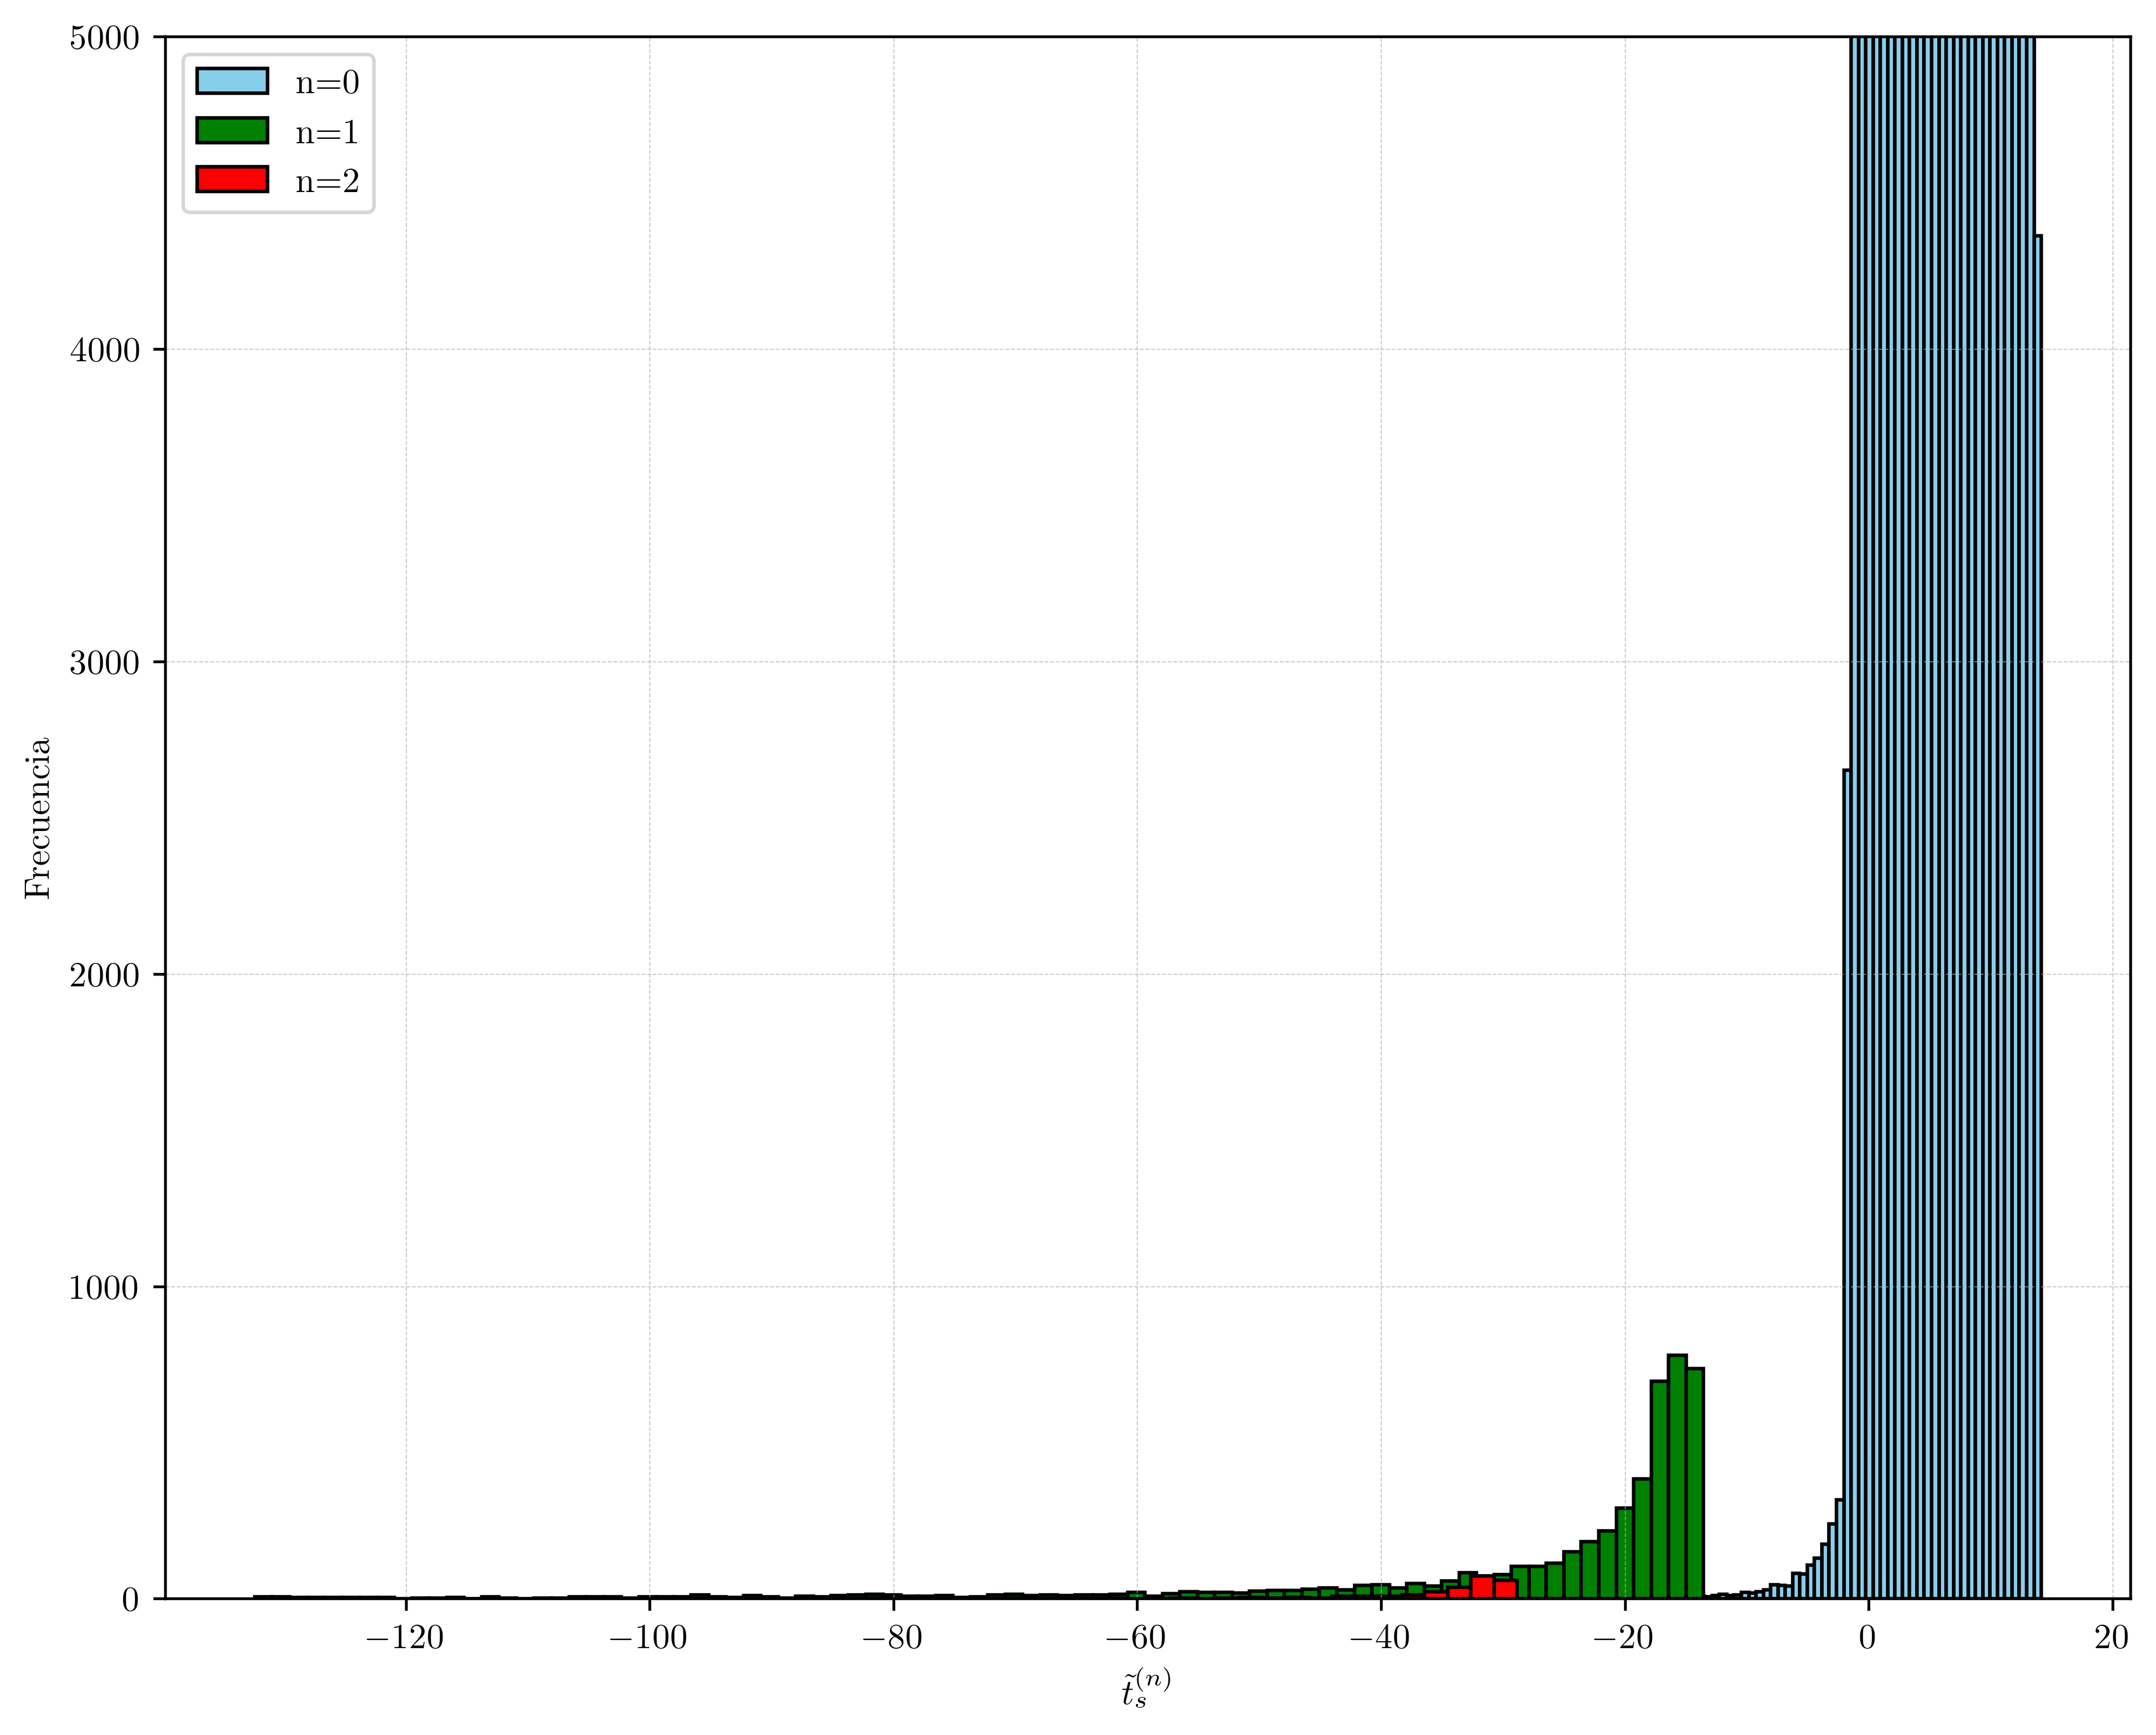

In [65]:
# Histogram without normalization

#Only if LaTeX is configured locally
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'


plt.figure(figsize=[10,8],dpi=400)
                                
plt.hist(t_renorm_0, bins=bins_freedman_diaconis1,  color='skyblue', edgecolor='black',label = "n=0")
plt.hist(t_renorm_1, bins=bins_freedman_diaconis1,  color='green', edgecolor='black',label = "n=1")
plt.hist(t_renorm_2, bins=bins_freedman_diaconis2,  color='red', edgecolor='black',label = "n=2")
plt.grid(True, linestyle='--', alpha=0.7,linewidth=0.3)

plt.ylim(0,5000)
plt.legend()
plt.xlabel(r'$\tilde{t}_s^{(n)}$')
plt.ylabel(r'$\mathrm{Frecuencia}$')

#plt.savefig(path_images + rf"\HistoGrama_i17_total.png",dpi=400,bbox_inches='tight')

plt.show()

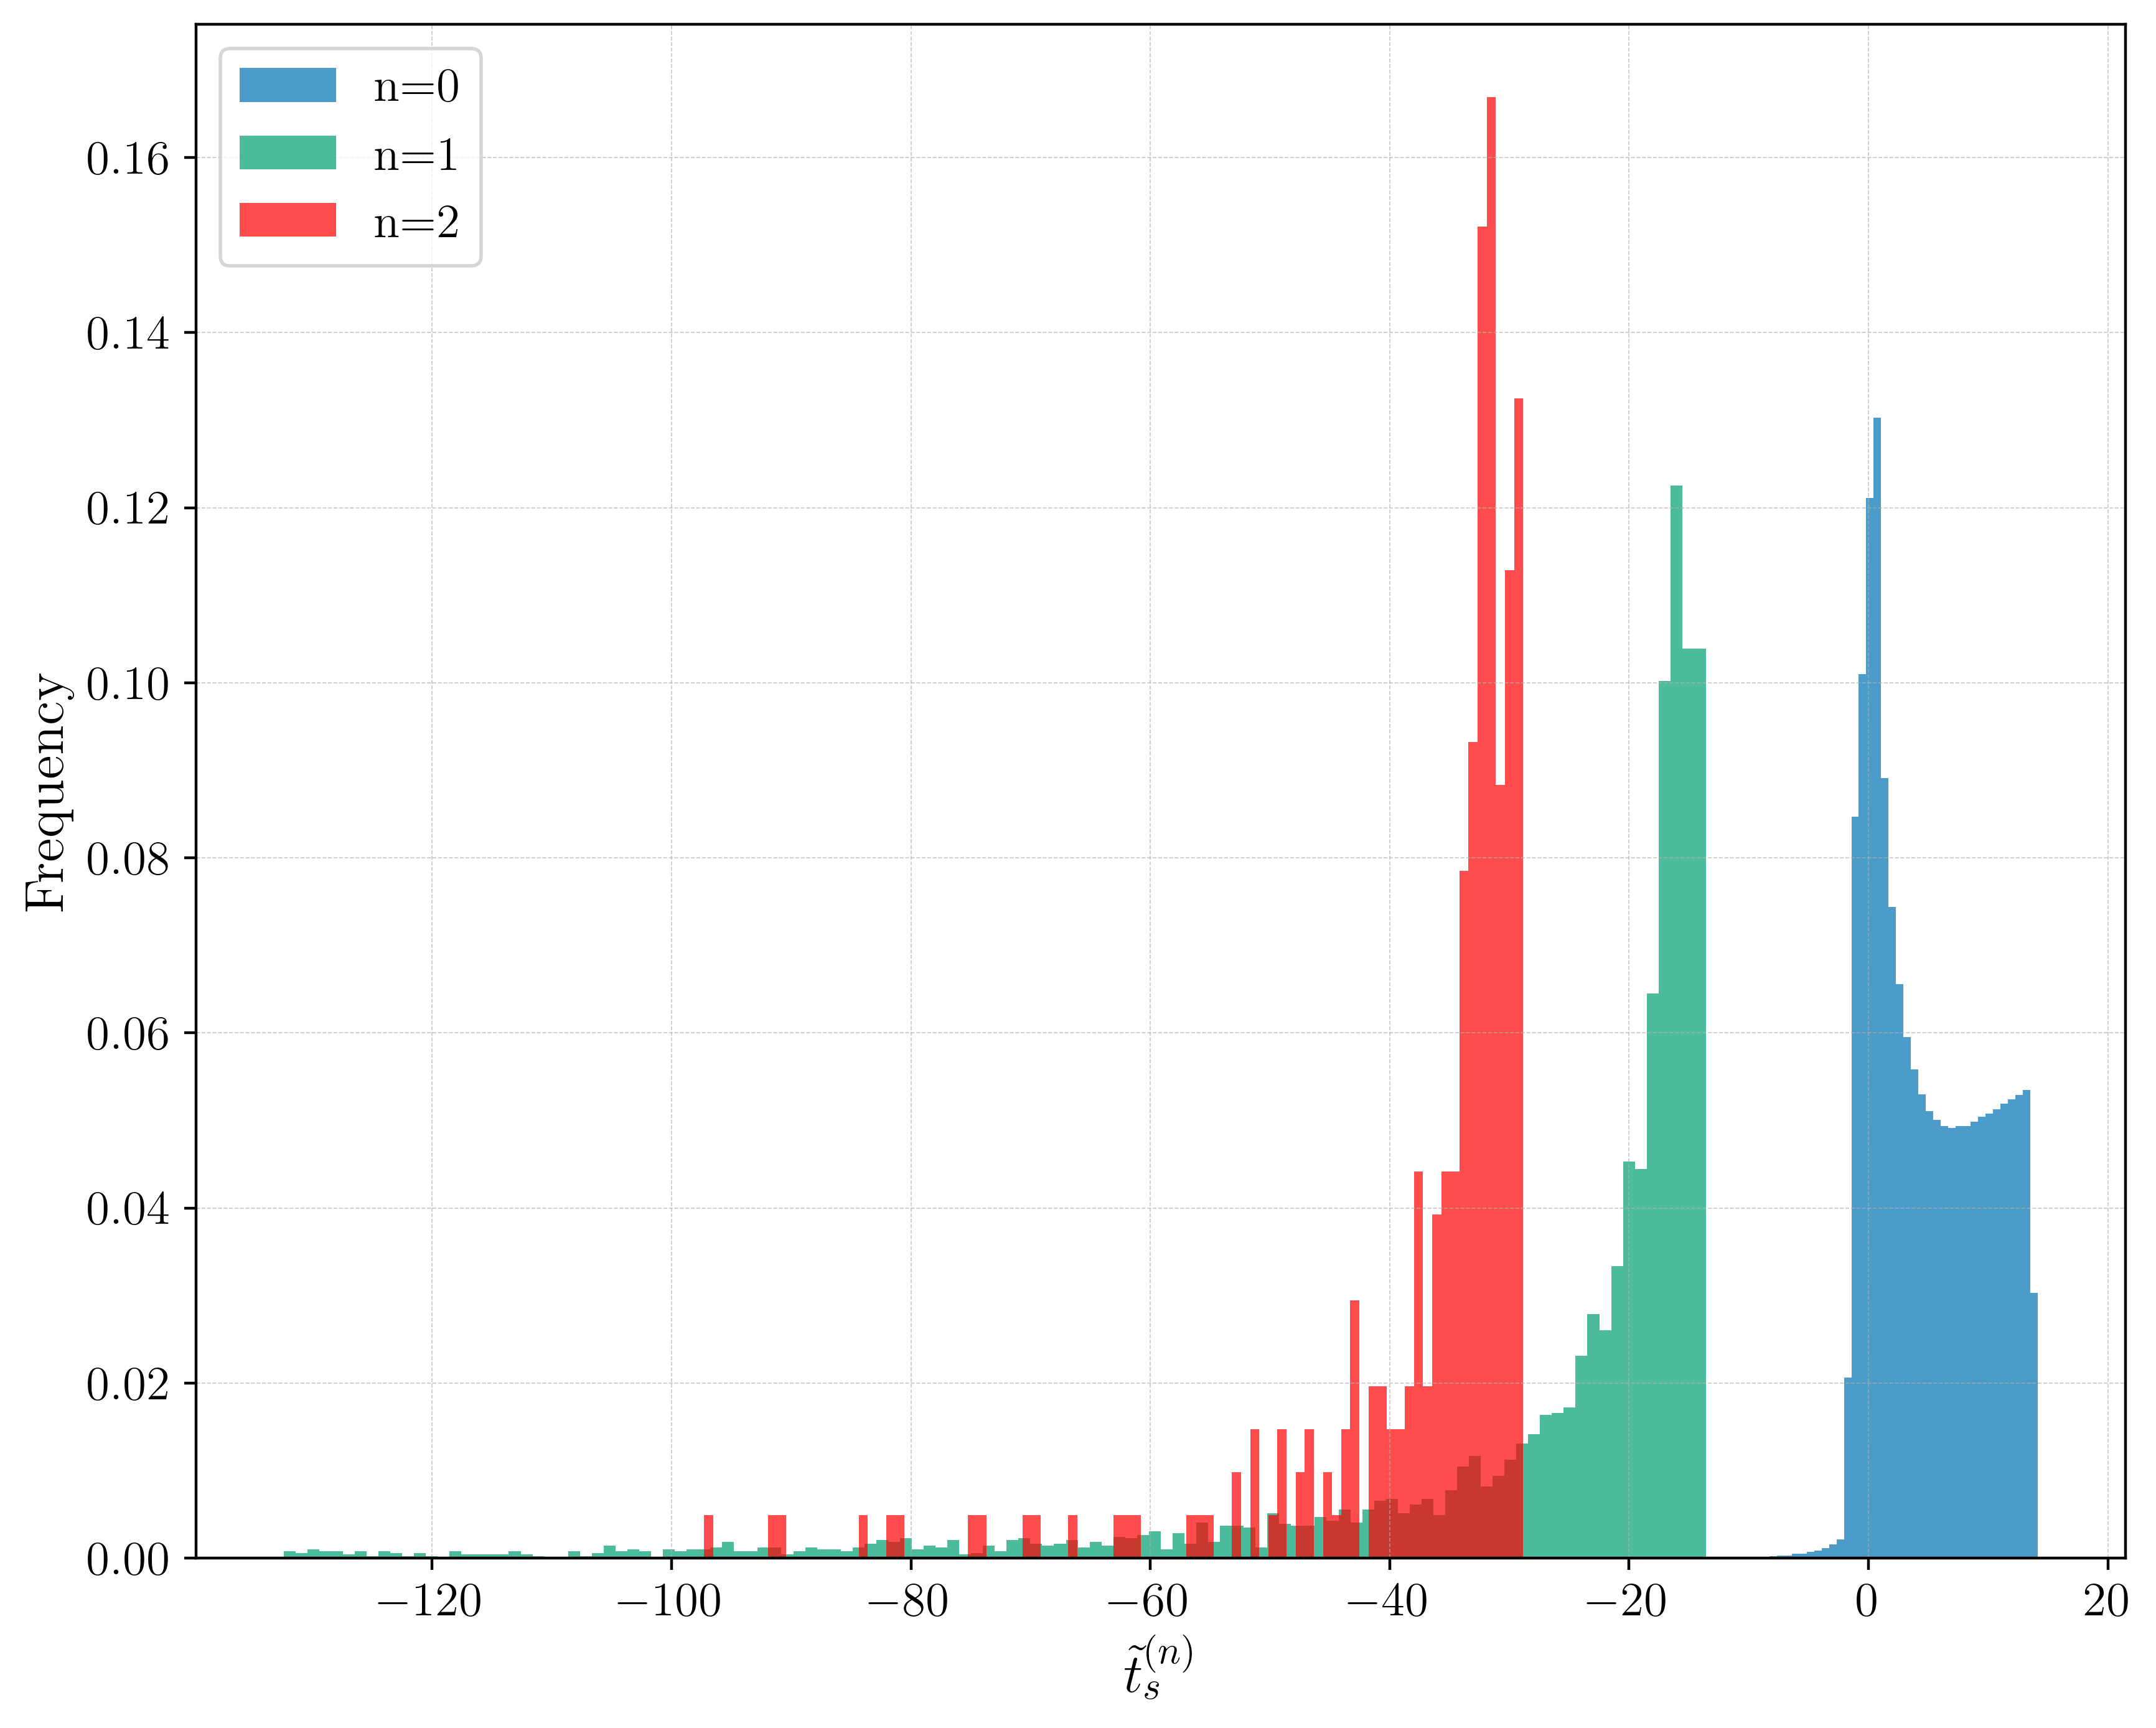

In [113]:
# Histogram with normalization based on the area of the distribution

#Only if LaTeX is configured locally
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'


plt.figure(figsize=[10,8], dpi=400)

plt.hist(t_renorm_0, bins=80, color='#0072B2', label="n=0", density=True, alpha=0.7)
plt.hist(t_renorm_1, bins=120, color='#009E73', label="n=1", density=True, alpha=0.7)
plt.hist(t_renorm_2, bins=90, color='red', label="n=2", density=True, alpha=0.7)

plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

#plt.savefig(path_images + rf"\HistoGrama_i17_norm_total.png",dpi=400,bbox_inches='tight')

plt.show()

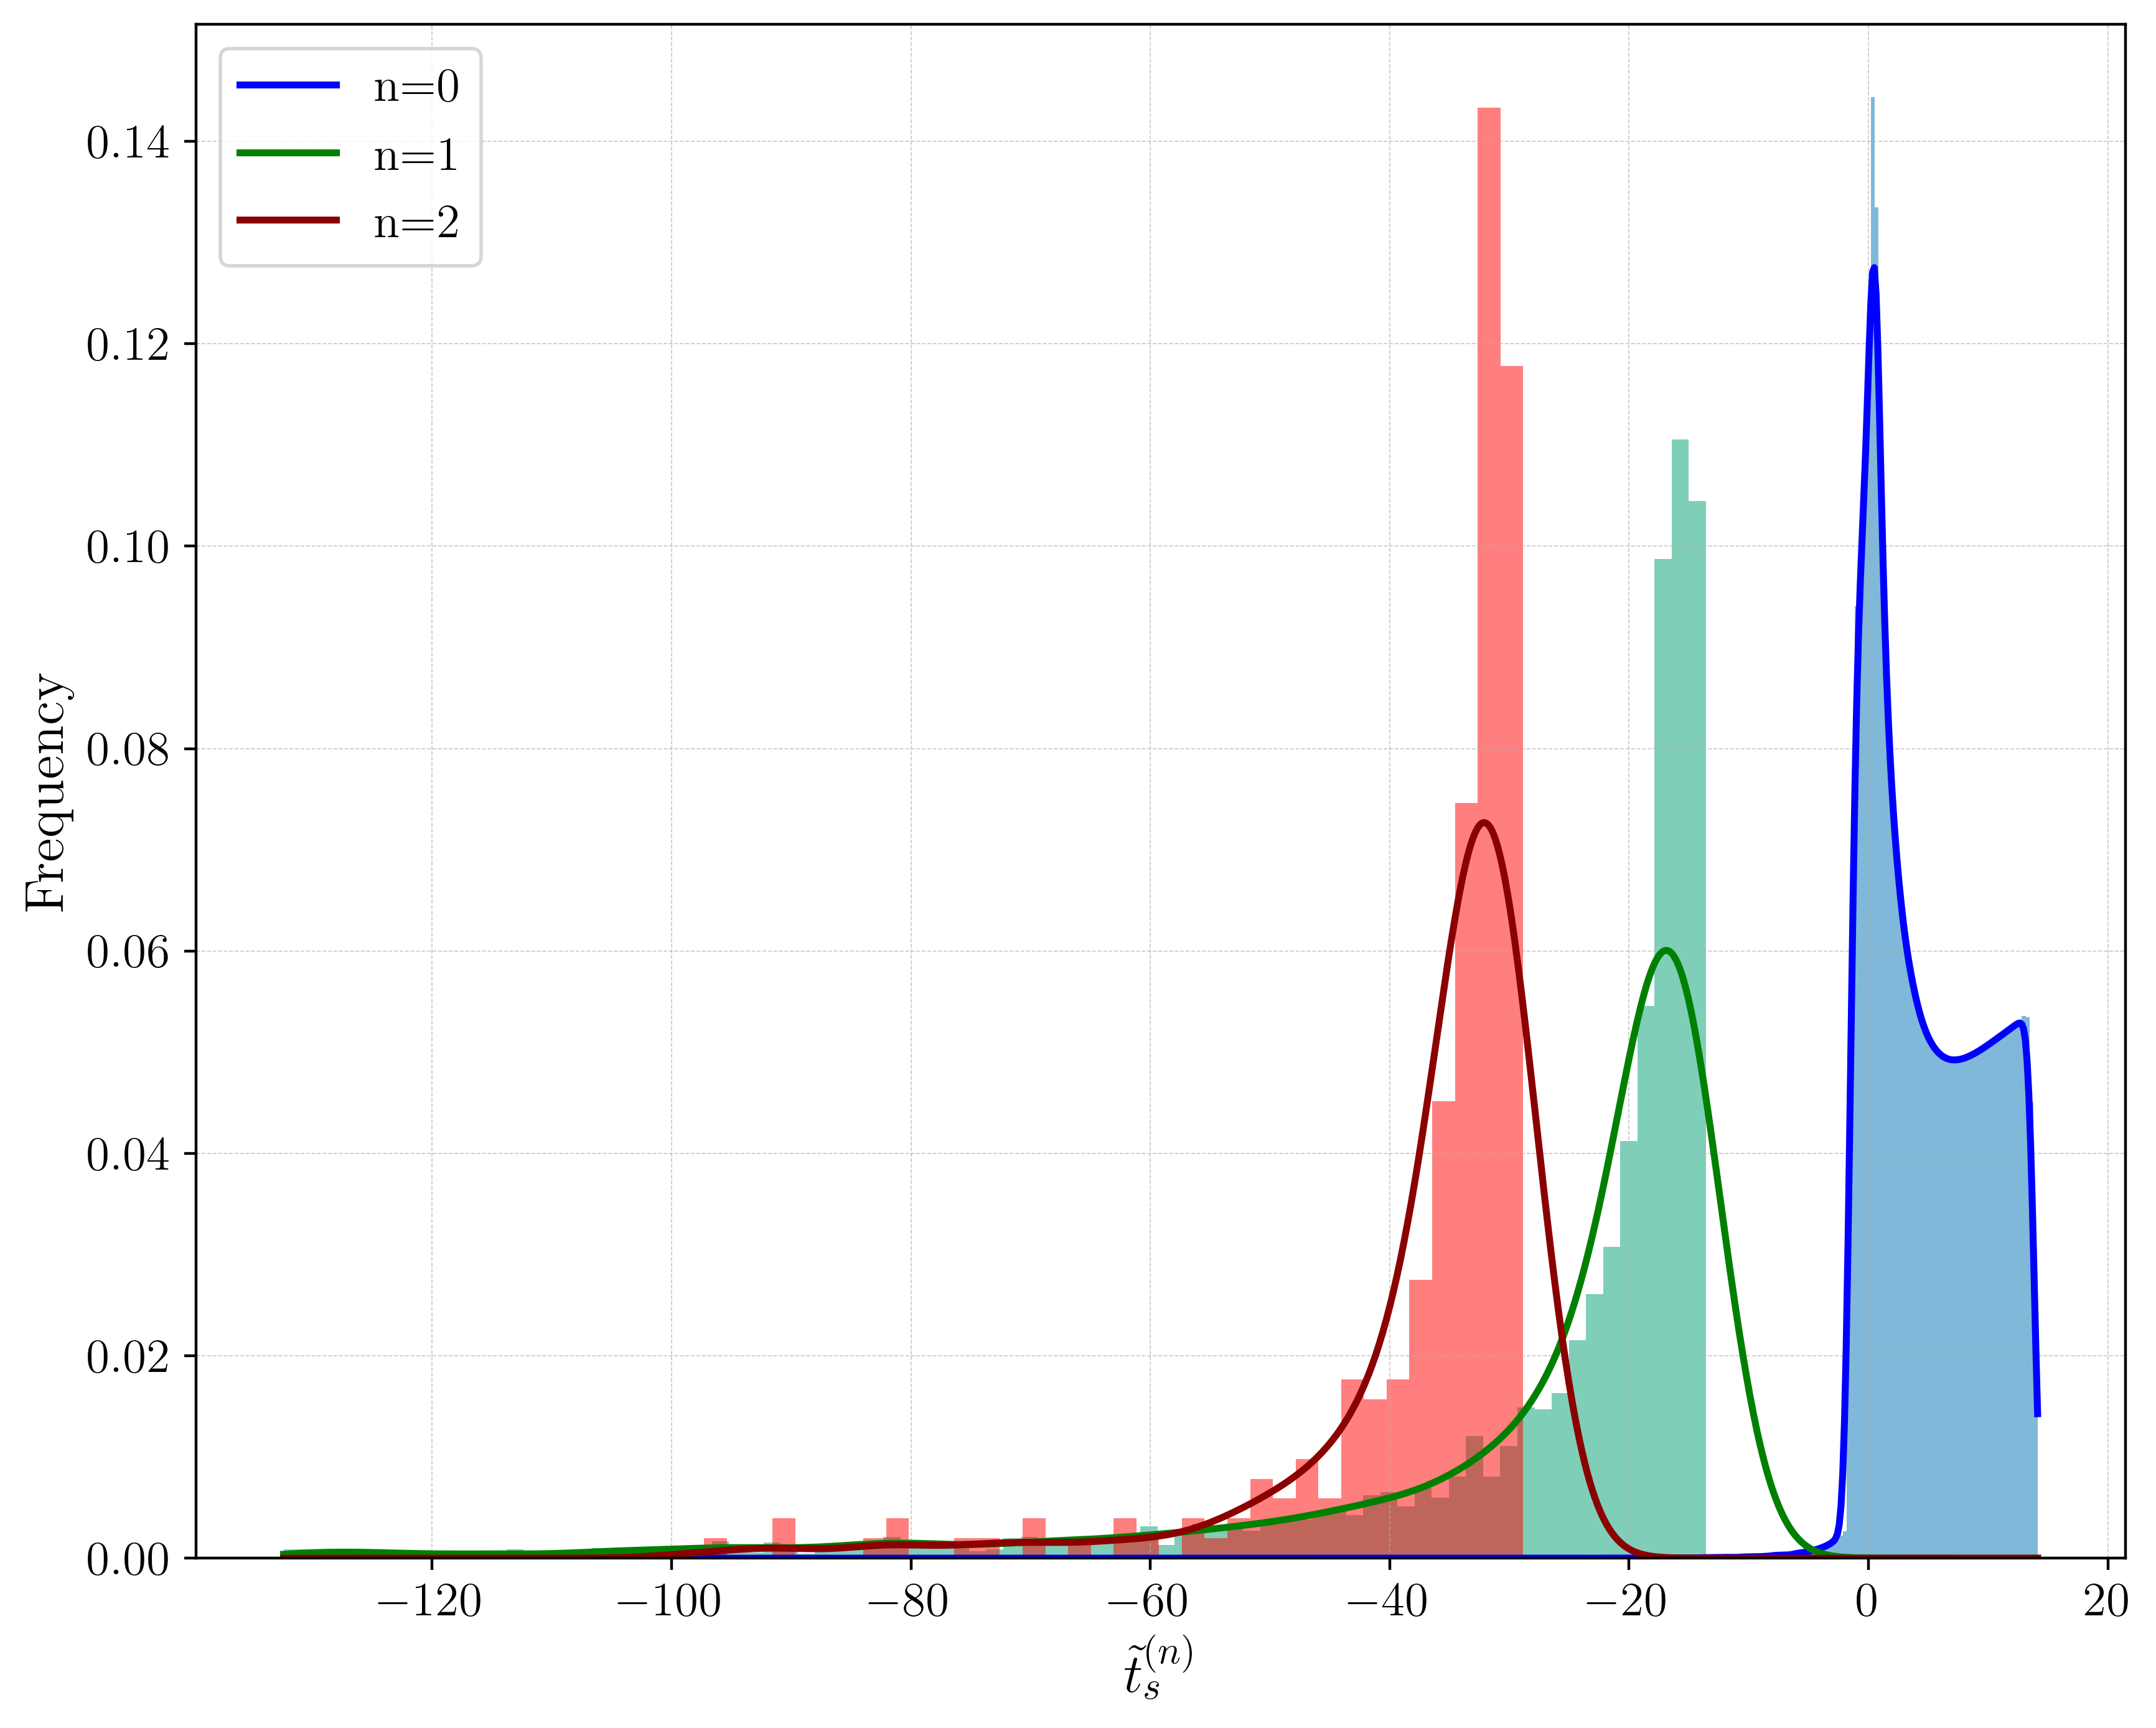

In [118]:
# Histogram with normalization based on the area of the distribution with curves distributions
from scipy.stats import gaussian_kde

# Common range
x_vals = np.linspace(min(np.min(t_renorm_0), np.min(t_renorm_1), np.min(t_renorm_2)),
                     max(np.max(t_renorm_0), np.max(t_renorm_1), np.max(t_renorm_2)),
                     1000)

# KDEs
kde0 = gaussian_kde(t_renorm_0)
kde1 = gaussian_kde(t_renorm_1)
kde2 = gaussian_kde(t_renorm_2)


plt.figure(figsize=[10,8], dpi=400)
plt.hist(t_renorm_0, bins=150, density=True, alpha=0.5,color="#0072B2")
plt.hist(t_renorm_1, bins=bins_freedman_diaconis1, density=True, alpha=0.5,color="#009E73")
plt.hist(t_renorm_2, bins=bins_freedman_diaconis2, density=True, alpha=0.5,color="red")

plt.plot(x_vals, kde0(x_vals), color="blue", lw=2, label="n=0")
plt.plot(x_vals, kde1(x_vals), color="green", lw=2, label="n=1")
plt.plot(x_vals, kde2(x_vals), color="darkred", lw=2, label="n=2")

plt.legend(loc='upper left', fontsize=14)
# Etiquetas
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

#plt.savefig(path_images + rf"HistoGrama_i17_NormCurv_total.png",dpi=400,bbox_inches='tight')
plt.show()

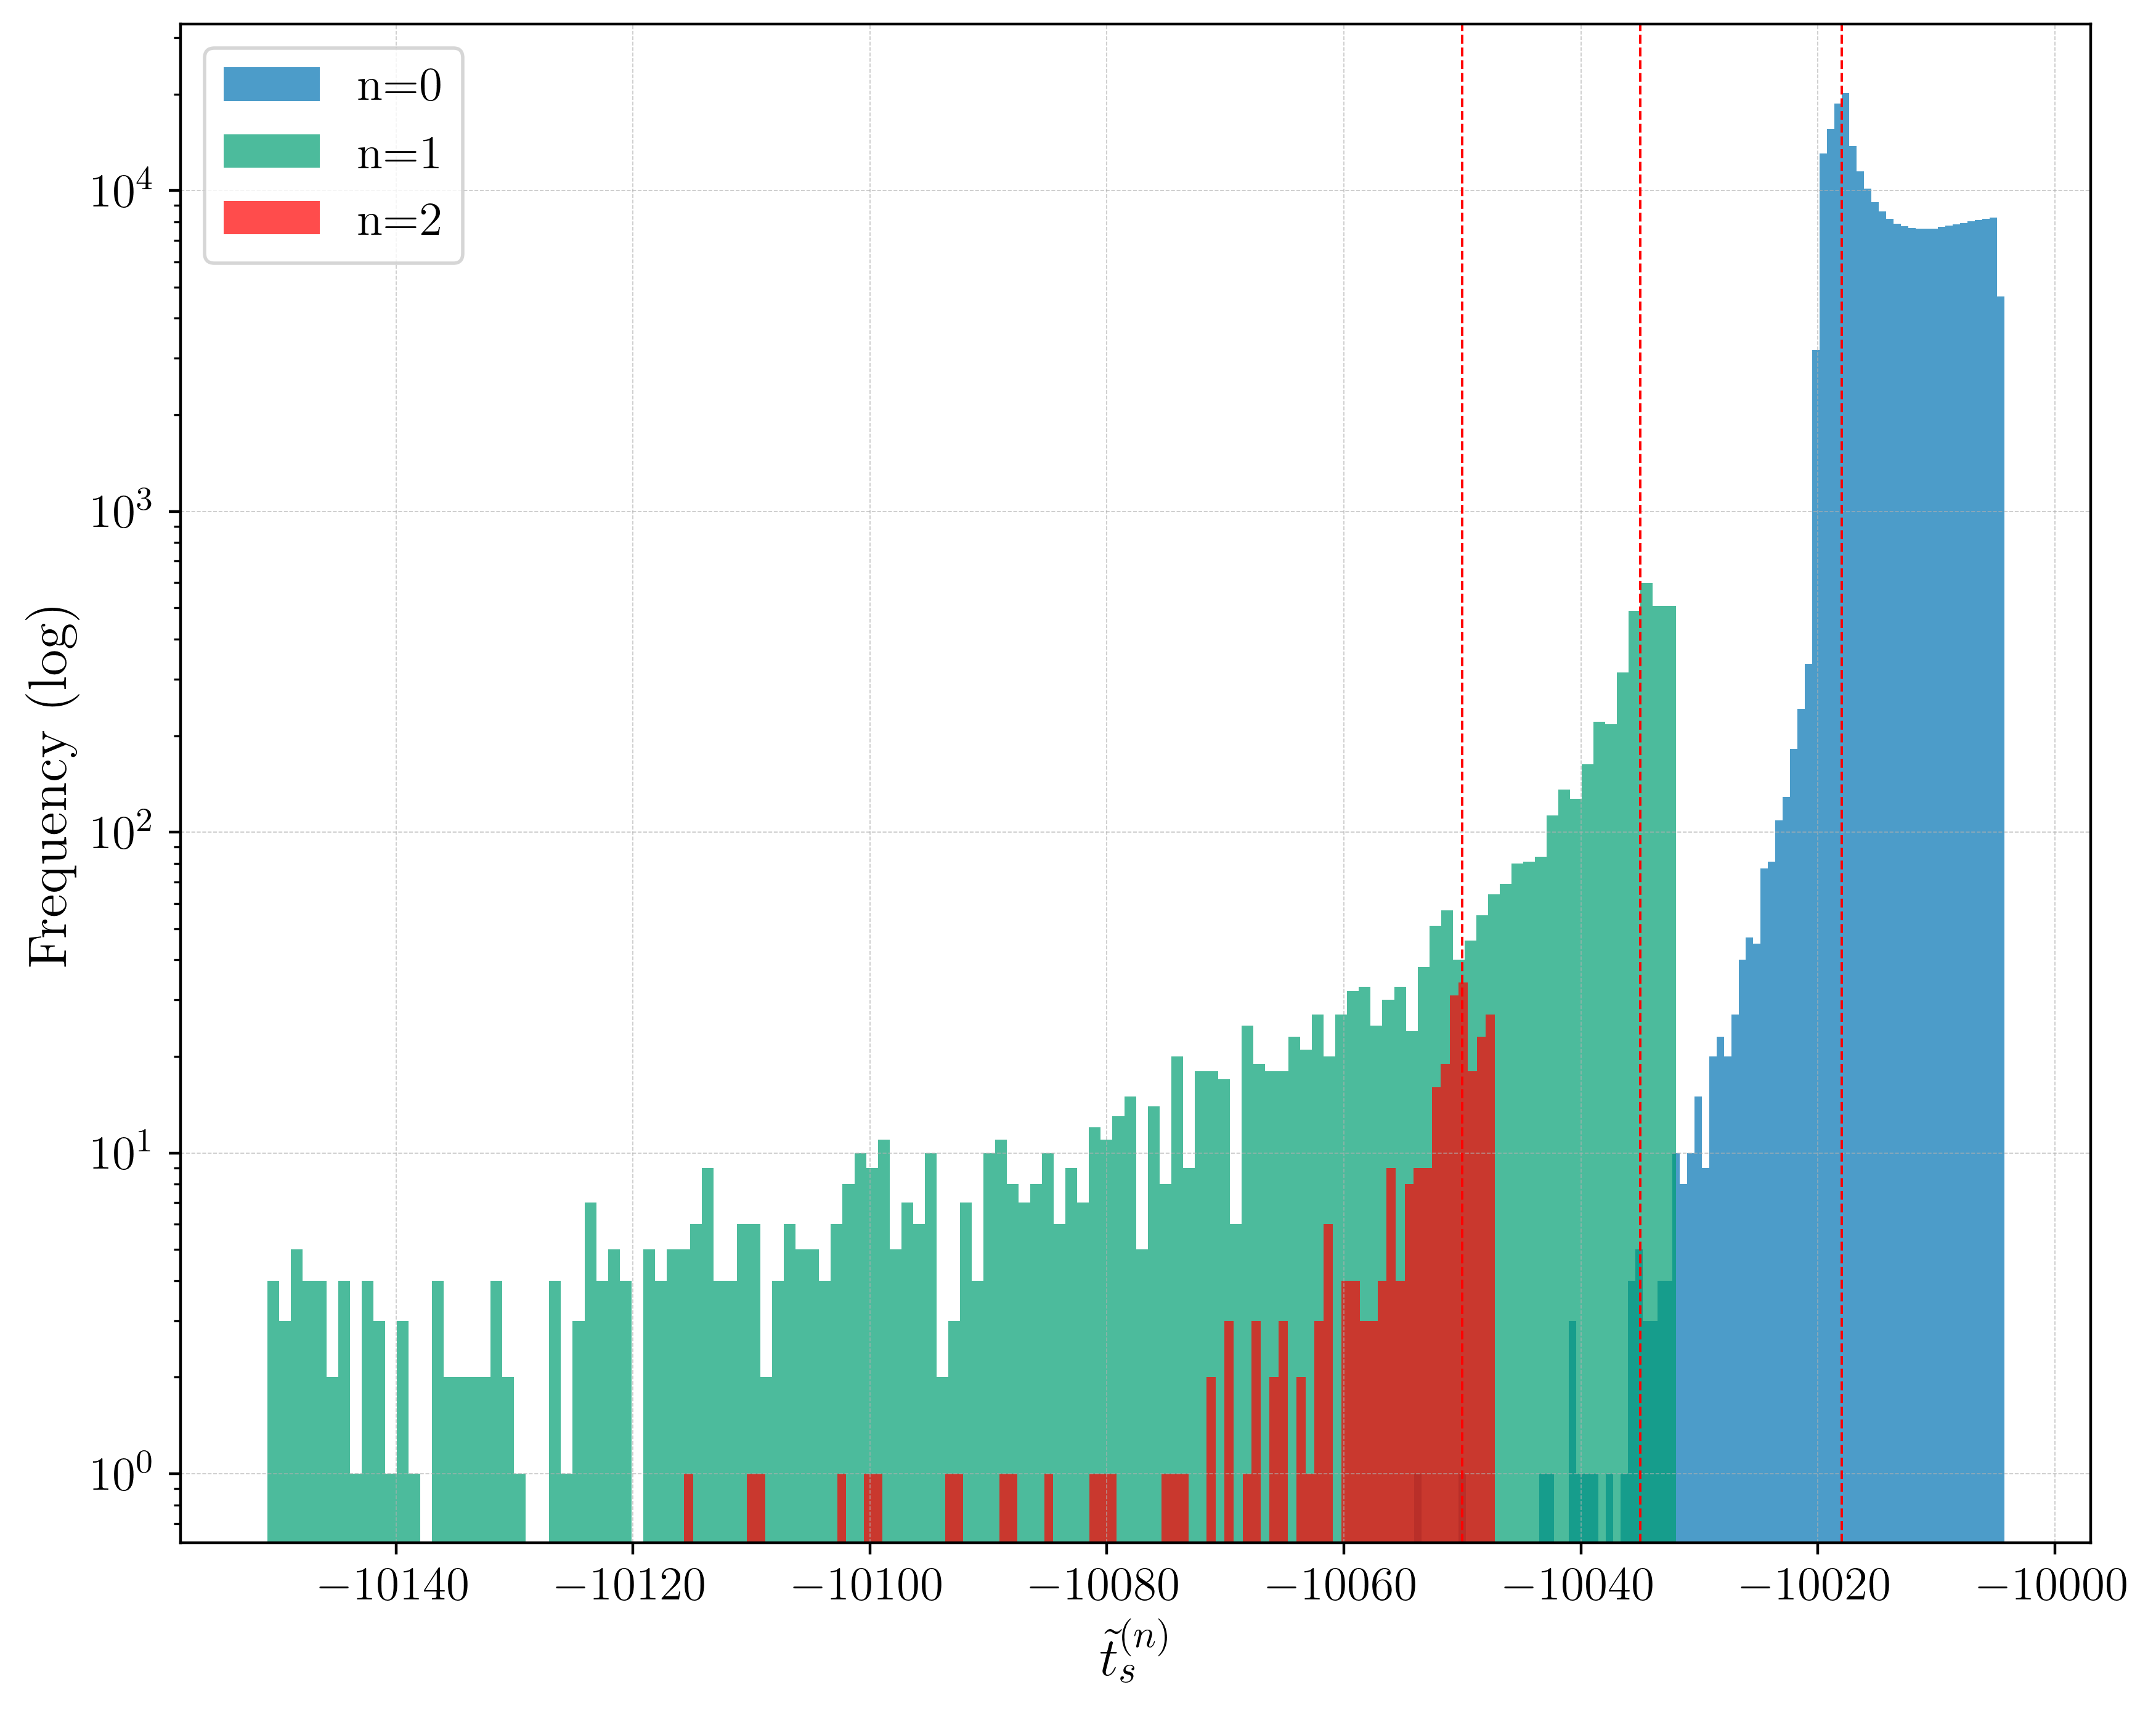

In [24]:
# Histogram with log of the frequency

#Only if LaTeX is configured locally
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Make histogram with log scale in y
plt.figure(figsize=[10,8], dpi=400)

plt.hist(t_renorm_0, bins=80, color='#0072B2', label="n=0", alpha=0.7)
plt.axvline(x=-10018, color='red', linestyle='--', linewidth=0.7)
plt.hist(t_renorm_1, bins=120, color='#009E73', label="n=1", alpha=0.7)
plt.axvline(x=-10035, color='red', linestyle='--', linewidth=0.7)
plt.hist(t_renorm_2, bins=90, color='red', label="n=2", alpha=0.7)
plt.axvline(x=-10050, color='red', linestyle='--', linewidth=0.7)


plt.yscale("log")  # logarithmic scale on the Y axis
plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency\ (log)}$', fontsize=16)

#plt.savefig(path_images + rf"\HistoGrama_i17_log_total.png",dpi=400,bbox_inches='tight')
plt.show()

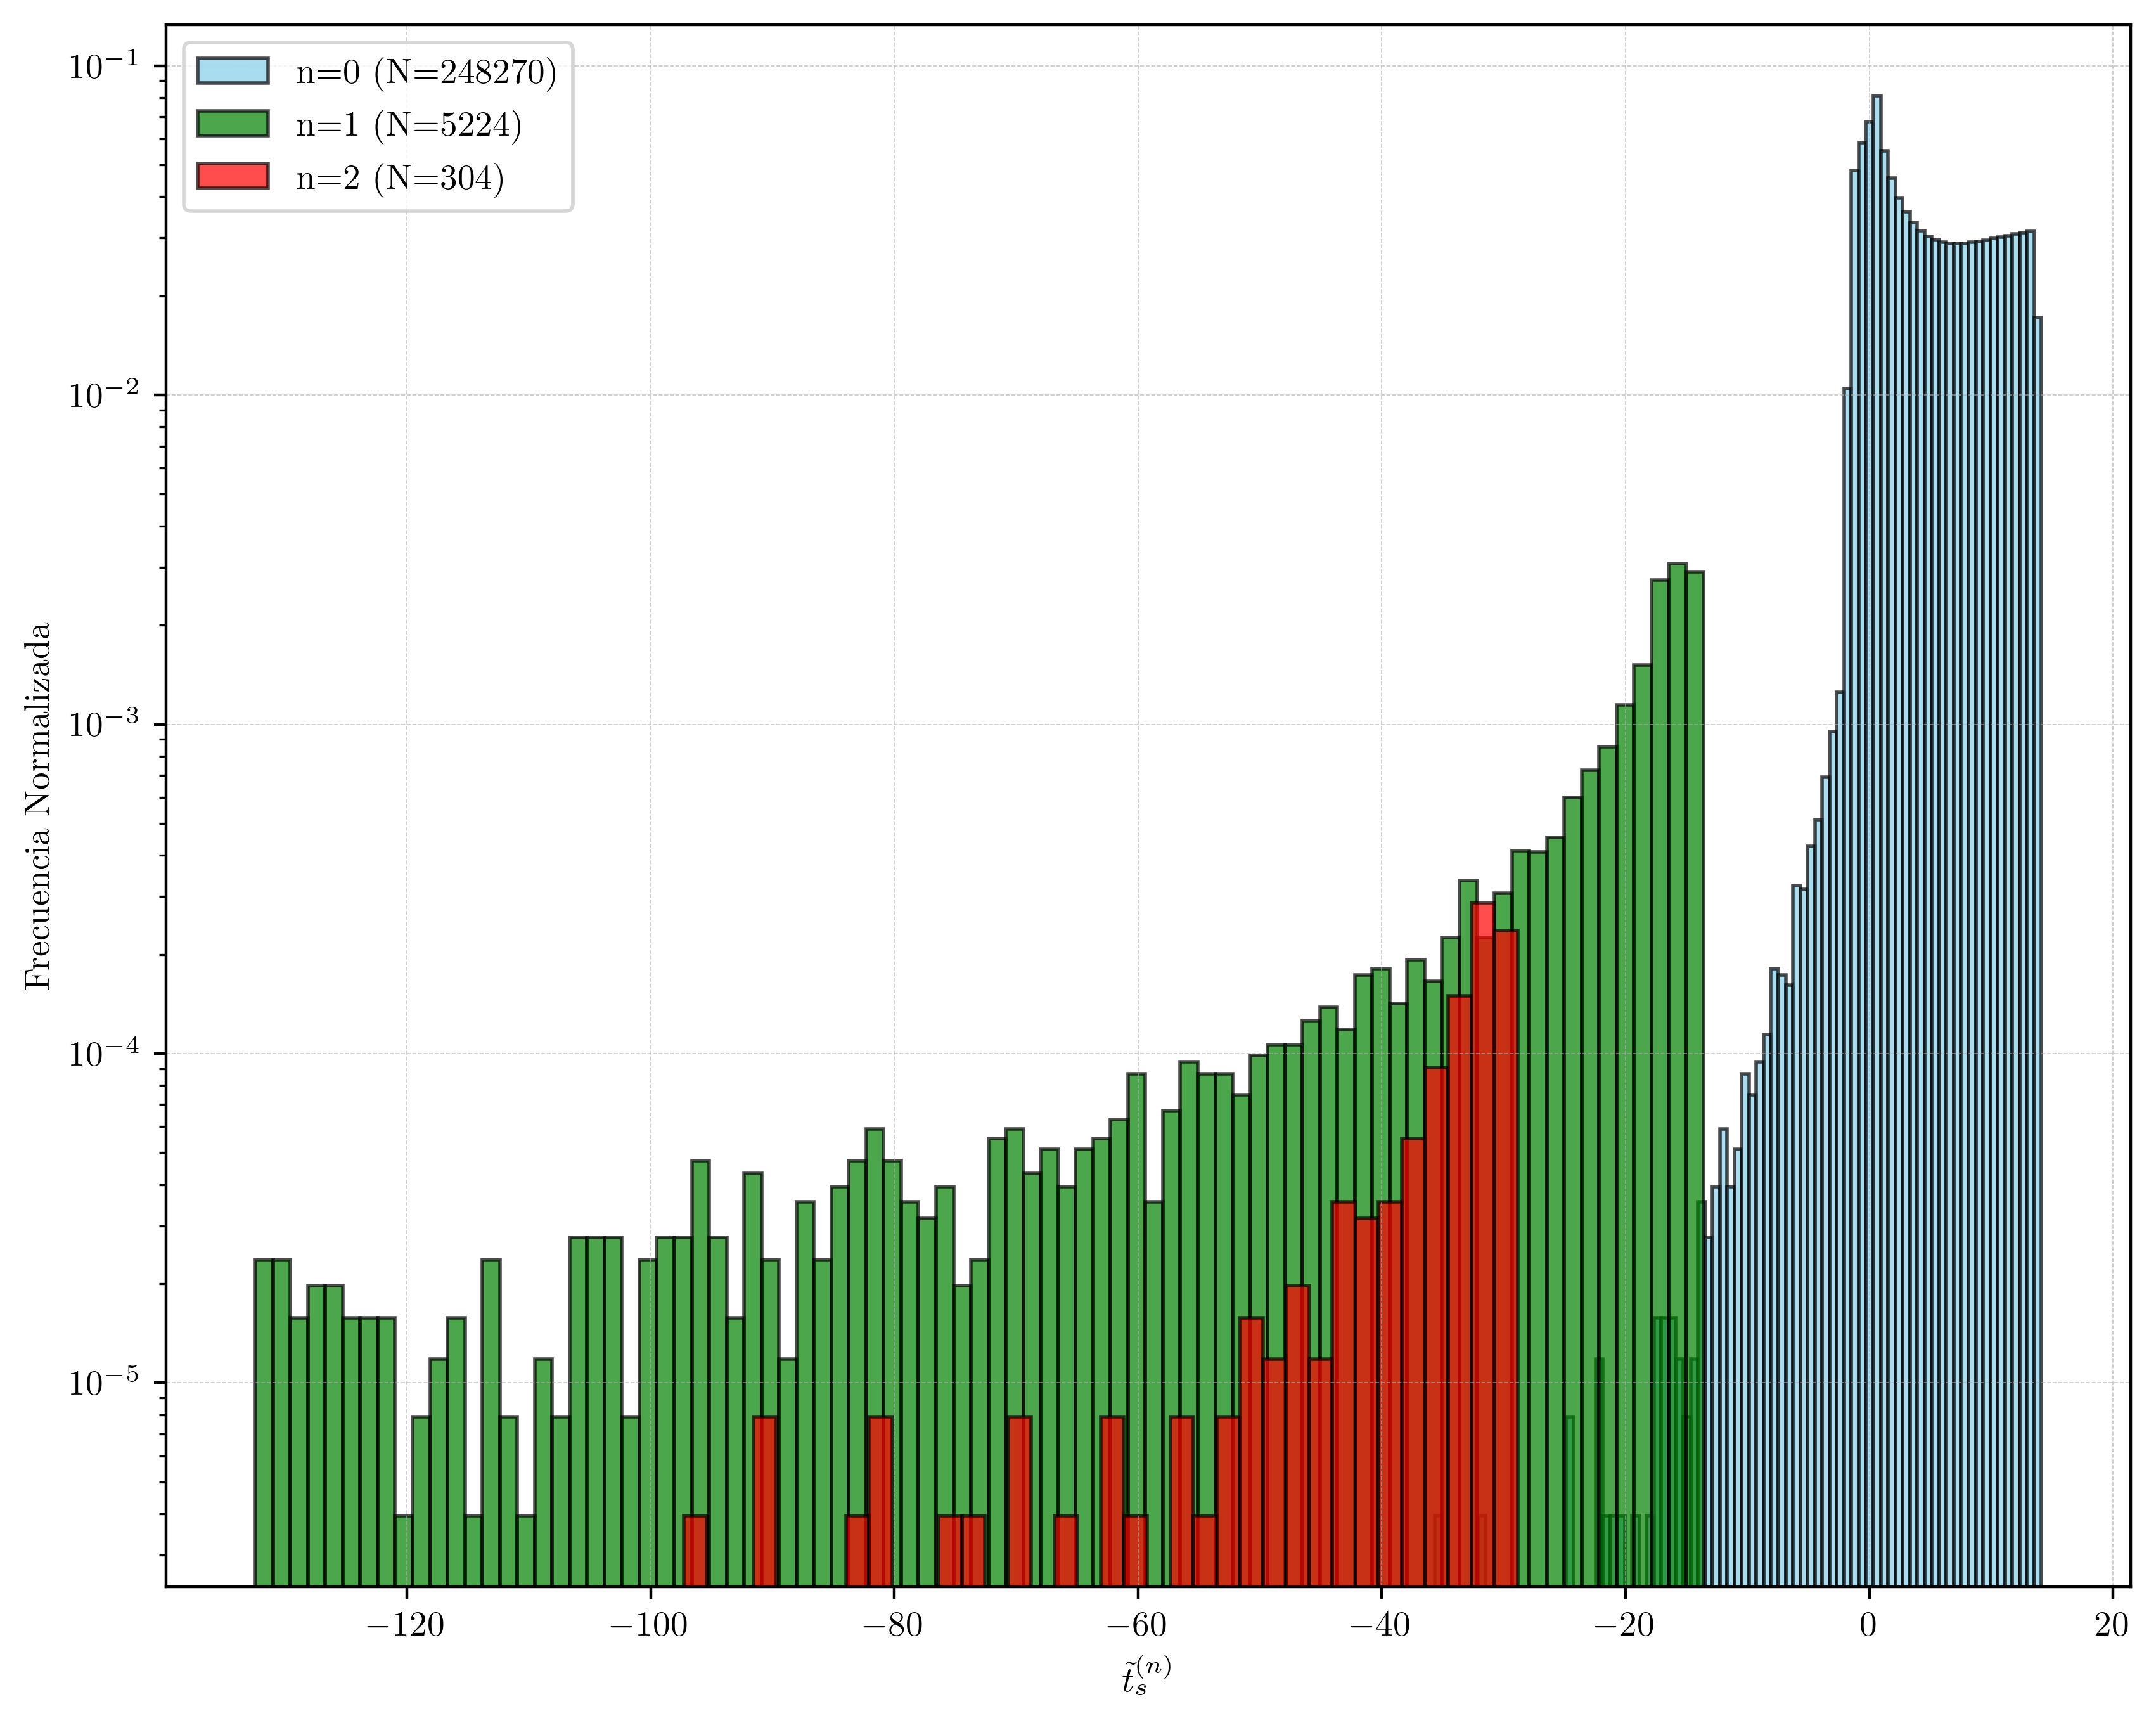

In [18]:
# Histogram with normalization based on the number of active pixels

# Only if LaTeX is configured locally
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

plt.figure(figsize=[10,8], dpi=400)

# Calcular pesos de normalización
N_live0 = mask0.sum() 
N_live1 = mask1.sum() 
N_live2 = mask2.sum()
N_live = N_live0 + N_live1 + N_live2
peso_0 = np.ones_like(t_renorm_0) / N_live
peso_1 = np.ones_like(t_renorm_1) / N_live  
peso_2 = np.ones_like(t_renorm_2) / N_live

# Histogramas normalizados
plt.hist(t_renorm_0, bins=bins_freedman_diaconis1, weights=peso_0, 
         color='skyblue', edgecolor='black', label=f"n=0 (N={N_live0})", alpha=0.7)

plt.hist(t_renorm_1, bins=bins_freedman_diaconis1, weights=peso_1,
         color='green', edgecolor='black', label=f"n=1 (N={N_live1})", alpha=0.7)

plt.hist(t_renorm_2, bins=bins_freedman_diaconis2, weights=peso_2,
         color='red', edgecolor='black', label=f"n=2 (N={N_live2})", alpha=0.7)

plt.yscale("log")  # logarithmic scale on the Y axis
plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)
plt.legend()
plt.xlabel(r'$\tilde{t}_s^{(n)}$')
plt.ylabel(r'$\mathrm{Frecuencia\ Normalizada}$')
#plt.savefig(path_images + rf"\HistoGrama_i17_total_normalized.png", dpi=400, bbox_inches='tight')
plt.show()

In [75]:
print("n=0:",len(t_renorm_0),N_live0,np.abs(len(t_renorm_0)-N_live0))
print("n=1:",len(t_renorm_1),N_live1,np.abs(len(t_renorm_1)-N_live1))
print("n=2:",len(t_renorm_2),N_live2,np.abs(len(t_renorm_2)-N_live2))

n=0: 248144 248270 126
n=1: 4929 5224 295
n=2: 268 304 36


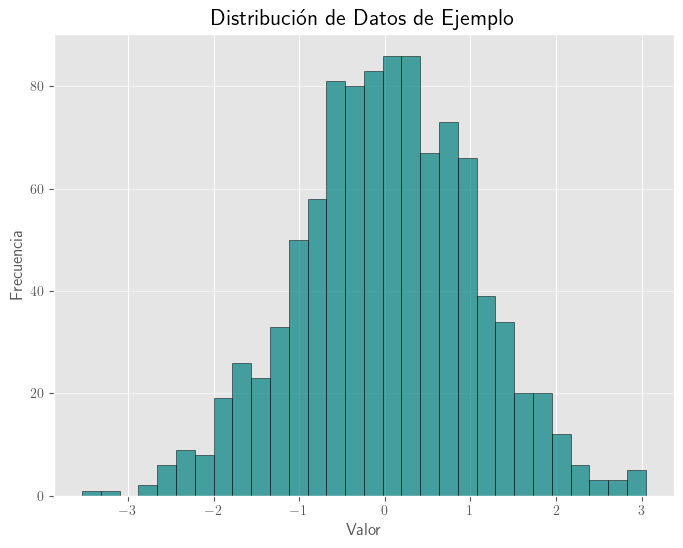

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
datos = np.random.randn(1000)

# Configurar estilo
plt.style.use('ggplot')

plt.figure(figsize=(8, 6)) # Ajusta el tamaño

# Crear el histograma
plt.hist(datos, bins=30, color='teal', edgecolor='black', alpha=0.7, histtype='bar') # O 'step', 'stepfilled'

# Añadir etiquetas y título
plt.title('Distribución de Datos de Ejemplo', fontsize=16)
plt.xlabel('Valor', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Mostrar leyenda si es necesario (para múltiples datasets)
# plt.legend()

plt.grid(axis='y', alpha=0.5) # Añade cuadrícula en Y

# Guarda la figura para el artículo
plt.savefig('histograma_articulo.pdf', dpi=300, bbox_inches='tight') # DPI alto, sin espacio extra

plt.show()

# Reducción de coordenadas

In [58]:
# Lensing bands params importation for i = 17
fnbands = path_lensingband17
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N17_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])

h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i17_dx0.1.h5


In [60]:
# Ray tracing params importation for i = 17
fnrays = path_raytracing17
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

h5f.close()

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i17_dx0.1.h5


In [62]:
#time renormalizartion 
t_renorm_17 = t0 + (D_obs + 2*np.log(D_obs))
alpha17 = supergrid0[:, 0]
beta17 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_17)
alpha17 = alpha17[valid_mask]
beta17 = beta17[valid_mask]
t_renorm_17 = t_renorm_17[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin17, Tmax17 = np.percentile(t_renorm_17, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_17),np.max(t_renorm_17))
print("filtered range of coordinates",Tmin17,Tmax17)

# Create a mask for the values within the range 
mask_in_range_17 = (t_renorm_17 >= Tmin17) & (t_renorm_17 <= Tmax17 )

#data filtering 
t_renorm_17 = t_renorm_17[mask_in_range_17]
alpha17 = alpha17[mask_in_range_17]
beta17 = beta17[mask_in_range_17]

original range of coordinates -35.667235246168275 14.249619164365868
filtered range of coordinates -35.667235246168275 14.138239200566256


In [64]:
from scipy import stats
mascara_bins_17 = Mask_FilterTime(t_renorm_17, 120)
datos_filtrados_por_bins_17 = t_renorm_17[mascara_bins_17]

# Resultados
print(f"\nDatos originales: {len(t_renorm_17)}")
print(f"Datos en top bins: {len(datos_filtrados_por_bins_17)}")
print(f"Porcentaje retenido: {len(datos_filtrados_por_bins_17)/len(t_renorm_17)*100:.2f}%")


Datos originales: 248144
Datos en top bins: 27728
Porcentaje retenido: 11.17%


In [66]:
# Lensing bands params importation for i = 60
fnbands = path_lensingband60
print("reading file:",fnbands)
h5f = h5py.File(fnbands,'r')

#Grid points information for each lensing band
supergrid0=h5f['grid0'][:]
N0=int(h5f["N0"][0])
mask0=h5f['mask0'][:]
N60_live0 = mask0.sum() 
lim0=int(h5f["lim0"][0])


h5f.close()

reading file: C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\LensignBands\LensingBands_a0.94_i60_dx0.1.h5


In [68]:
# Ray tracing params importation for i = 60
fnrays = path_raytracing60
#Imprimimos la dirección donde ]se encuentran
print("Reading file: ",fnrays)
h5f = h5py.File(fnrays,'r')

#We extract all the information from the .h5 file.
rs0=h5f['rs0'][:]
sign0=h5f['sign0'][:]
t0=h5f['t0'][:]
phi0=h5f['phi0'][:]

Reading file:  C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\RayTracing\Rays_a0.94_i60_dx0.1.h5


In [70]:
#time renormalizartion 
t_renorm_60 = t0 + (D_obs + 2*np.log(D_obs))
alpha60 = supergrid0[:, 0]
beta60 = supergrid0[:, 1]

valid_mask = np.isfinite(t_renorm_60)
alpha60 = alpha60[valid_mask]
beta60 = beta60[valid_mask]
t_renorm_60 = t_renorm_60[valid_mask]

#data filtering by percentiles
minV = 0
maxV = 99.95
Tmin60, Tmax60 = np.percentile(t_renorm_60, [minV,maxV])
print("original range of coordinates",np.min(t_renorm_60),np.max(t_renorm_60))
print("filtered range of coordinates",Tmin60,Tmax60)

# Create a mask for the values within the range 
mask_in_range_60 = (t_renorm_60 >= Tmin60) & (t_renorm_60 <= Tmax60 )

#data filtering 
t_renorm_60 = t_renorm_60[mask_in_range_60]
alpha60 = alpha60[mask_in_range_60]
beta60 = beta60[mask_in_range_60]

original range of coordinates -34.796777076264334 50.90384215697486
filtered range of coordinates -34.796777076264334 50.83806008011077


In [72]:
mascara_bins = Mask_FilterTime(t_renorm_60, 120)
datos_filtrados_por_bins_60 = t_renorm_60[mascara_bins]

print(f"\nDatos originales: {len(t_renorm_60)}")
print(f"Datos en top bins: {len(datos_filtrados_por_bins_60)}")
print(f"Porcentaje retenido: {len(datos_filtrados_por_bins_60)/len(t_renorm_60)*100:.2f}%")


Datos originales: 247996
Datos en top bins: 7831
Porcentaje retenido: 3.16%


In [74]:
from scipy.stats import gaussian_kde

def mode_kde(data, gridsize=2000):
    data = np.asarray(data)
    xgrid = np.linspace(data.min(), data.max(), gridsize)
    kde = gaussian_kde(data)
    dens = kde(xgrid)
    mode_idx = np.argmax(dens)
    return xgrid[mode_idx], xgrid, dens


In [100]:
##### ancho a media altura
def fwhm_from_kde(data, height ,gridsize=2000):
    mode, xgrid, dens = mode_kde(data, gridsize=gridsize)
    imax = np.argmax(dens)
    half = dens[imax] * height

    # izquierda
    left_idx = np.where(dens[:imax] < half)[0]
    left = xgrid[left_idx[-1]] if len(left_idx) > 0 else xgrid[0]

    # derecha
    right_idx = np.where(dens[imax:] < half)[0]
    right = xgrid[imax + right_idx[0]] if len(right_idx) > 0 else xgrid[-1]

    return left, right, right - left, mode

Ancho_17 = fwhm_from_kde(t_renorm_17,mode_17,0.2)
Ancho_60 = fwhm_from_kde(t_renorm_60,mode_60,0.2)

In [76]:
#### highest density interval 
def modal_hdi_kde(data, p=0.68, gridsize=4000):
    """
    Compute a modal highest-density interval (HDI) from a kernel density estimate (KDE).
    This function estimates the probability density of the input data using a Gaussian
    KDE, identifies the mode as the location of maximum estimated density, and then
    finds the connected interval around that mode that contains approximately a target
    probability mass `p`.
    :param data: One-dimensional sample of data points.
    :param p: Target probability mass to be enclosed by the modal HDI. Must be between 0 and 1.
    :param gridsize: Number of grid points used to evaluate the KDE between the minimum and maximum of the data.
    
    :returns: A tuple containing:
              - mode: location of the KDE mode
              - left: left boundary of the modal HDI
              - right: right boundary of the modal HDI
              - width: interval width, computed as right - left
              - mass: approximate probability mass enclosed in the interval
              - threshold: density threshold defining the interval
    """
    data = np.asarray(data)
    # Filtrar valores no finitos
    data_finite = data[np.isfinite(data)]
    
    kde = gaussian_kde(data_finite)
    xgrid = np.linspace(data_finite.min(), data_finite.max(), gridsize)
    dens = kde(xgrid)

    dx = xgrid[1] - xgrid[0]
    probs = dens * dx
    mode_idx = np.argmax(dens)
    mode = xgrid[mode_idx]
    
    # Binary search over the density threshold
    lo, hi = 0.0, dens[mode_idx]

    best = None

    for _ in range(60):
        c = (lo + hi) / 2.0
        mask = dens >= c

        # Connected component containing the mode
        if not mask[mode_idx]:
            hi = c
            continue

        i = mode_idx
        l = i
        while l > 0 and mask[l - 1]:
            l -= 1
        r = i
        while r < len(mask) - 1 and mask[r + 1]:
            r += 1

        mass = probs[l:r+1].sum()

        if mass >= p:
            lo = c
            best = (mode, xgrid[l], xgrid[r], xgrid[r] - xgrid[l],  mass, c)
        else:
            hi = c

    return best  # (mode, left, right, width = right - left, mass, threshold)

ancho_17 = modal_hdi_kde(t_renorm_17,0.2)
ancho_60 = modal_hdi_kde(t_renorm_60,0.2)

print(ancho_17)
print(ancho_60)

(0.43824831443343015, -0.5456541351310875, 1.173061536260093, 1.7187156713911804, 0.2008720815989719, 0.1002346011457825)
(-5.588043189251788, -14.624762910893498, -2.354524995015062, 12.270237915878436, 0.20014164453851674, 0.014729145697857283)


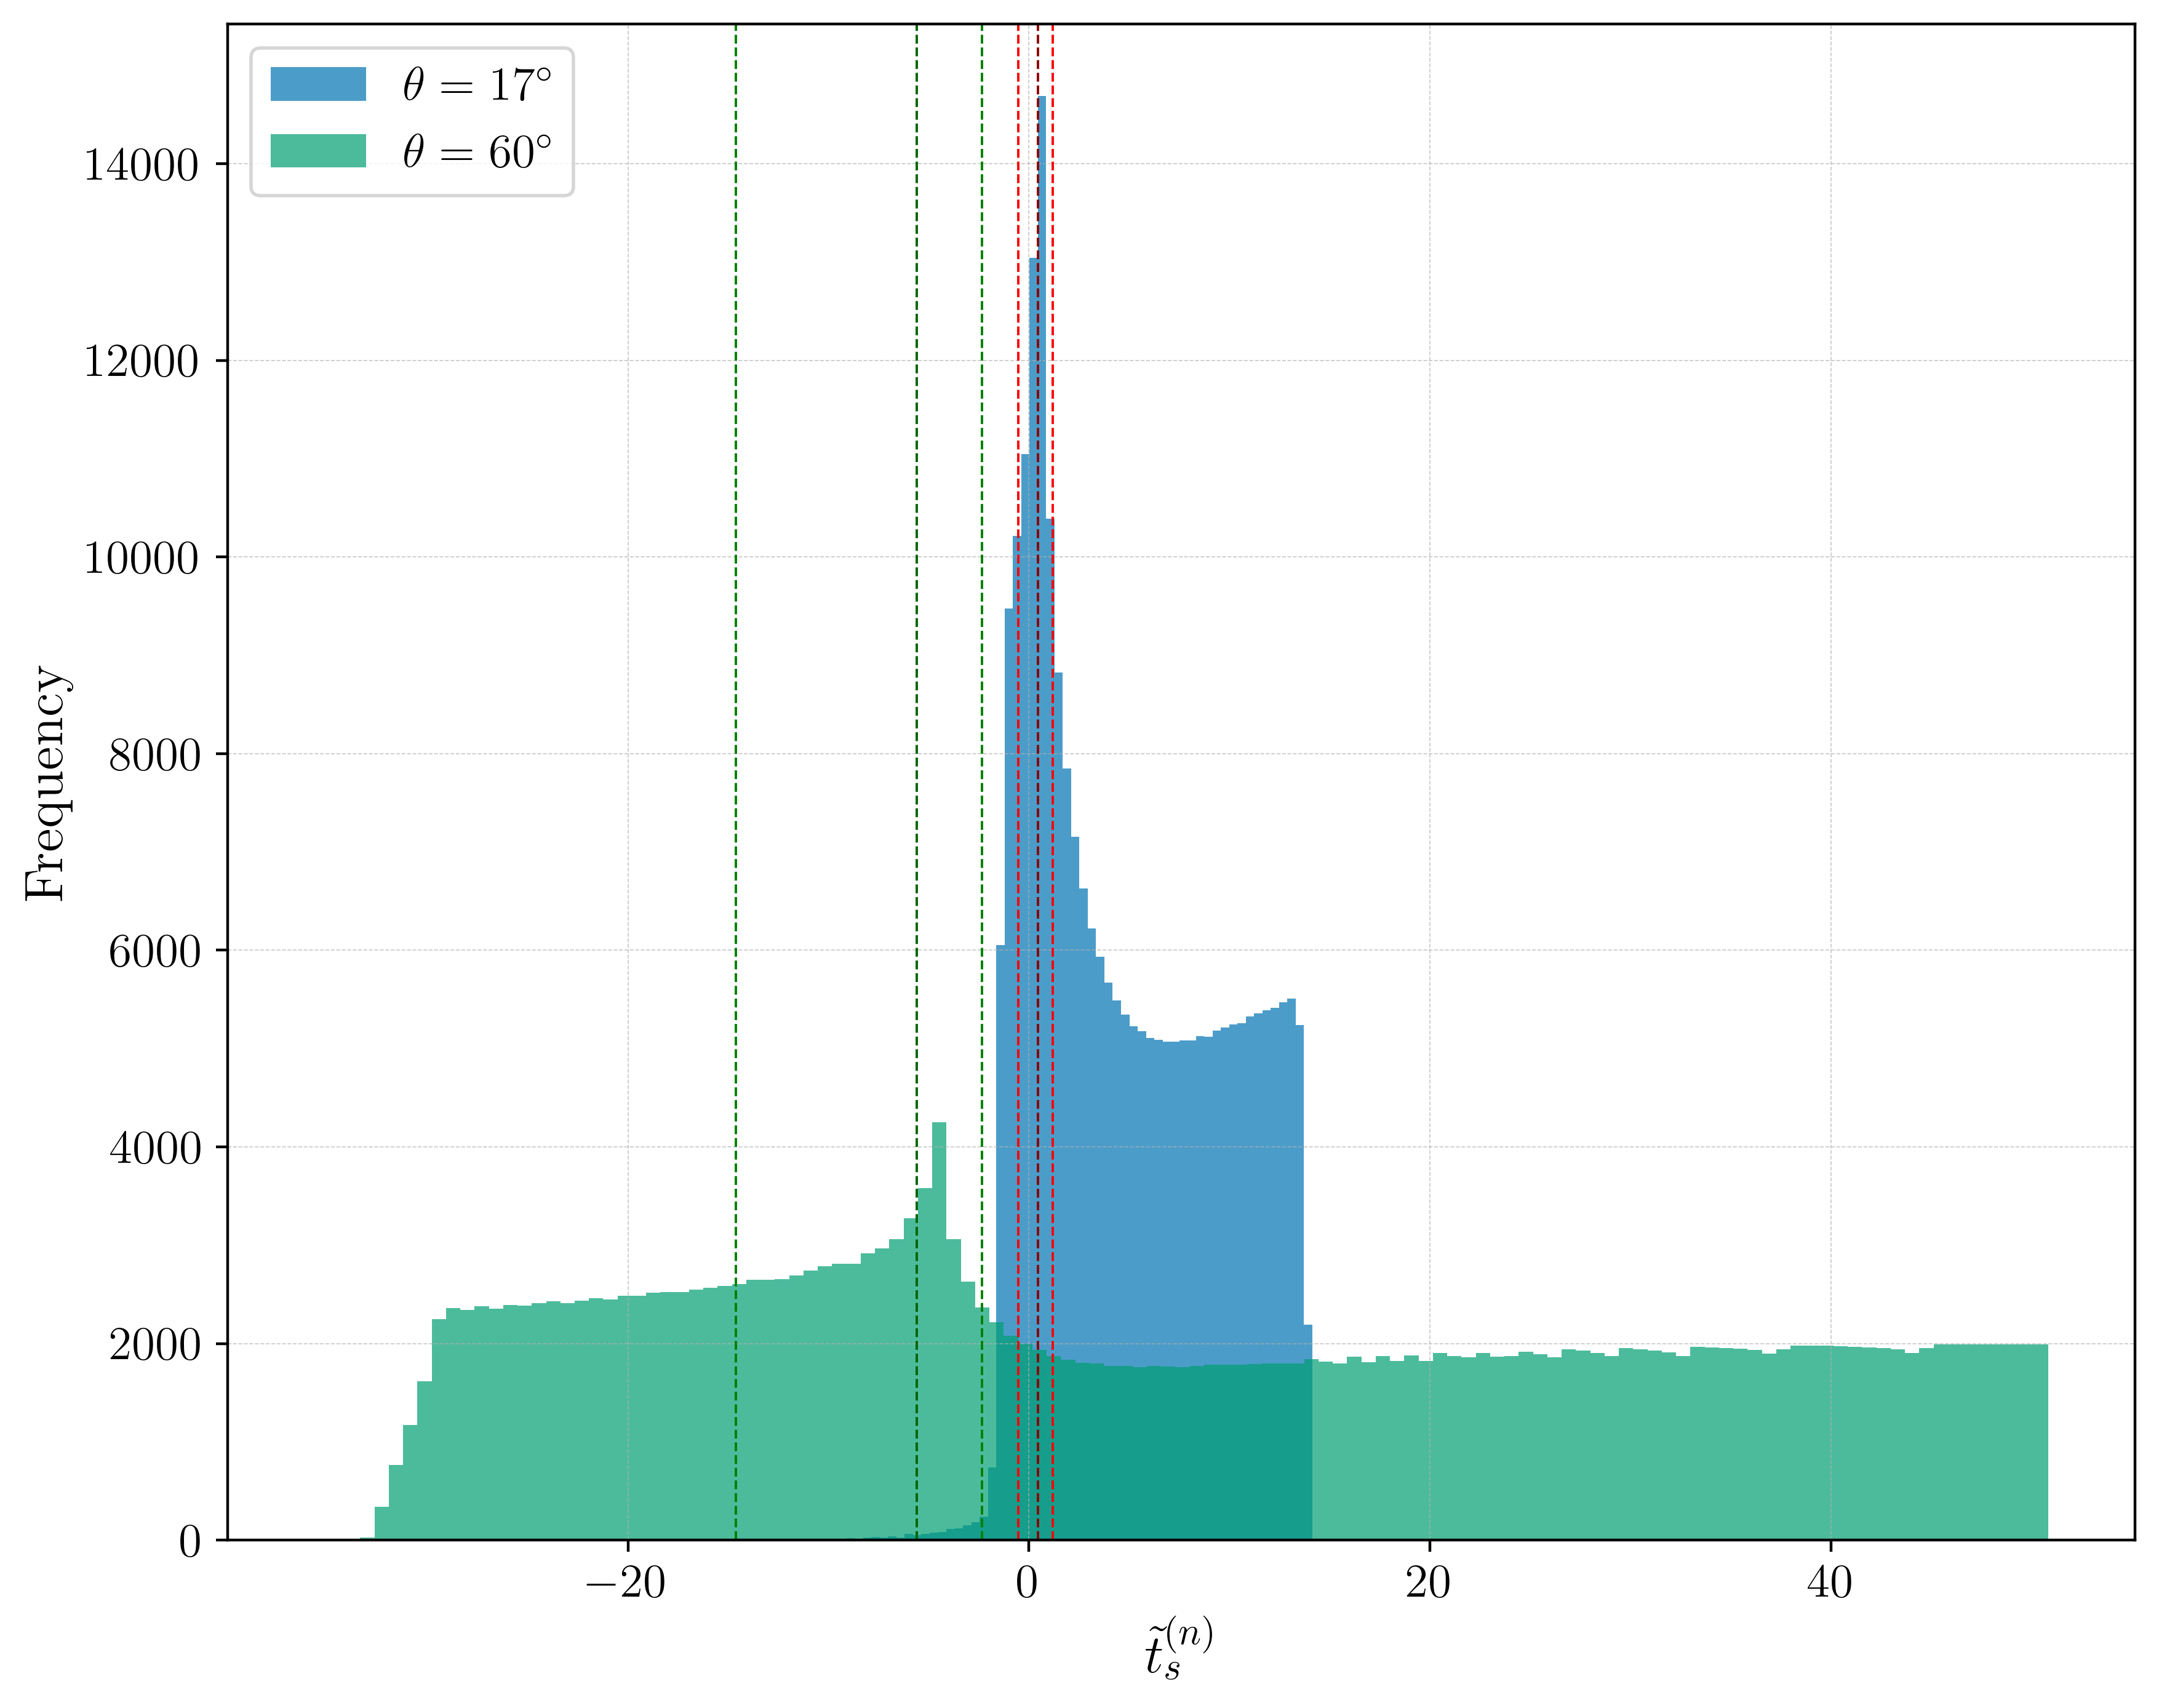

In [77]:
import matplotlib as mpl
import matplotlib.pyplot as plt

#Only if LaTeX is configured locally
mpl.rcParams['text.usetex'] = True  
mpl.rcParams['font.family'] = 'serif'

# Create the normalized histogram
plt.figure(figsize=[10,8], dpi=400)

#peso_17 = np.ones_like(t_renorm_17) / N17_live0
#peso_60 = np.ones_like(t_renorm_60) / N60_live0

plt.hist(t_renorm_17, bins=120, color='#0072B2', label=r"$\theta = 17^{\circ}$", density=False, alpha=0.7)
#plt.axvline(x=np.min(datos_filtrados_por_bins_17), color='red', linestyle='--', linewidth=0.7)
#plt.axvline(x=np.max(datos_filtrados_por_bins_17), color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=ancho_17[1], color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=ancho_17[2], color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=ancho_17[0], color='darkred', linestyle='--', linewidth=0.7)


plt.hist(t_renorm_60, bins=120, color='#009E73', label=r"$\theta = 60^{\circ}$", density=False, alpha=0.7)
#plt.axvline(x=np.min(datos_filtrados_por_bins_60), color='red', linestyle='--', linewidth=0.7)
#plt.axvline(x=np.max(datos_filtrados_por_bins_60), color='red', linestyle='--', linewidth=0.7)
plt.axvline(x=ancho_60[1], color='green', linestyle='--', linewidth=0.7)
plt.axvline(x=ancho_60[2], color='green', linestyle='--', linewidth=0.7)
plt.axvline(x=ancho_60[0], color='darkgreen', linestyle='--', linewidth=0.7)


plt.grid(True, linestyle='--', alpha=0.7, linewidth=0.3)

plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel(r'$\tilde{t}_s^{(n)}$', fontsize=16)
plt.ylabel(r'$\mathrm{Frequency}$', fontsize=16)

#plt.savefig(path_images + rf"\HistoGrama_origi_total.png",dpi=400,bbox_inches='tight')

plt.show()

In [9]:
import similaritymeasures
import numpy as np
from scipy.integrate import simpson
from scipy.spatial.distance import euclidean
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True  # Si tienes LaTeX instalado
mpl.rcParams['font.family'] = 'serif'

In [11]:
def FluxFactor(fluxes):
    maxflux = np.max(fluxes)
    minflux = np.min(fluxes)
    avgflux = np.mean(fluxes)
    stdflux = np.std(fluxes)


#    print("Max= ", maxflux," Min= ", minflux," Avg= ", avgflux," Std= ", stdflux)

    target_flux = 0.6
    fluxfactor = target_flux/avgflux
    return fluxes*fluxfactor

In [38]:
path_slc17 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ShortTime\ShortTimeReal_LightCurve_datas_dx0.1_dt0.48828125_dtM0.48828125_a0.94_i60_inoisy_n0.4_i0.94_ft1000_spatial512_snap2048.csv"
LC_data_17 = pd.read_csv(path_slc17)
LC_data_17

,Inoisy data,BriskLight n=0,FastLight n=0,SlowLight n=0,BriskLight n=1,FastLight n=1,SlowLight n=1,BriskLight n=2,FastLight n=2,SlowLight n=2,BriskLight,FastLight,SlowLight,Time
0,32.019728,147.450151,990.422827,955.710583,0.000000,219.270715,172.589375,0.0,10.256350,17.327819,147.450151,1219.949892,1145.627777,0.000000
1,32.373188,176.807363,998.059184,948.259360,0.000000,222.898879,163.395416,0.0,10.824586,17.004056,176.807363,1231.782650,1128.658831,0.488520
2,32.634479,204.566628,1003.746738,942.429535,0.000000,225.248815,156.320809,0.0,11.113564,16.564558,204.566628,1240.109117,1115.314902,0.977040
3,32.760592,232.892500,1007.831797,938.883261,0.000000,226.248879,151.410294,0.0,11.215572,16.757715,232.892500,1245.296249,1107.051270,1.465559
4,33.239361,261.980773,1017.802051,937.017341,0.000000,228.740225,150.392573,0.0,11.325330,17.103003,261.980773,1257.867606,1104.512917,1.954079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2043,32.153304,621.454203,996.702235,995.454762,214.162085,203.499971,214.162085,0.0,10.904749,19.966092,835.616288,1211.106954,1229.582939,998.045921
2044,31.825053,590.054668,993.911011,983.669221,205.849084,202.410143,205.849084,0.0,11.067904,19.684246,795.903752,1207.389058,1209.202550,998.534441
2045,31.637795,557.585060,989.157292,972.722748,195.452880,201.800176,195.452880,0.0,10.402086,19.316203,753.037940,1201.359554,1187.491831,999.022960
2046,31.791184,523.800878,987.754292,963.645255,183.904115,202.557653,183.904115,0.0,10.364814,18.327158,707.704993,1200.676759,1165.876527,999.511480


In [40]:
lc_data_17sl =  FluxFactor(LC_data_17["SlowLight"])
lc_data_17fl =  FluxFactor(LC_data_17["FastLight"])
lc_data_17bl =  FluxFactor(LC_data_17["BriskLight"])

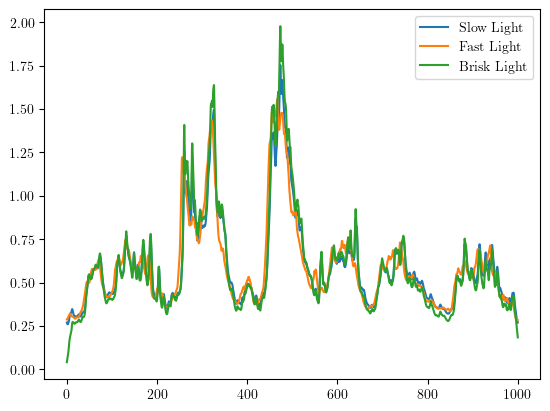

In [44]:
plt.plot(LC_data_17["Time"],lc_data_17sl,label="Slow Light")
plt.plot(LC_data_17["Time"],lc_data_17fl,label="Fast Light")
plt.plot(LC_data_17["Time"],lc_data_17bl,label="Brisk Light")
#plt.xlim(200,600)
plt.legend()
plt.show()

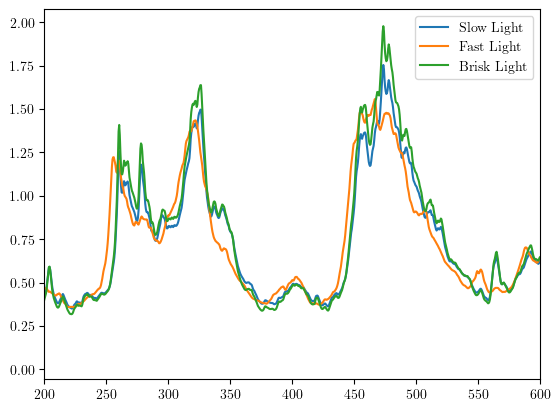

In [46]:
plt.plot(LC_data_17["Time"],lc_data_17sl,label="Slow Light")
plt.plot(LC_data_17["Time"],lc_data_17fl,label="Fast Light")
plt.plot(LC_data_17["Time"],lc_data_17bl,label="Brisk Light")
plt.xlim(200,600)
plt.legend()
plt.show()

In [27]:
BriskImage = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ShortTime\ImageDisplacedFastLight_a_0.94_i_17_1000.h5"
FastImage  = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ShortTime\ImageFastLight_a_0.94_i_17_1000.h5"
SlowImage  = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\ShortTime\Dynamical_Image_a_0.94_i_17.h5"

In [29]:
h5f = h5py.File(SlowImage,'r')
Is0=h5f['bghts0'][:]
Is1=h5f['bghts1'][:]
Is2=h5f['bghts2'][:]
h5f.close()


In [31]:
h5f = h5py.File(BriskImage,'r')
Ib0=h5f['bghts0'][:]
Ib1=h5f['bghts1'][:]
Ib2=h5f['bghts2'][:]
h5f.close()


In [33]:
h5f = h5py.File(FastImage,'r')
I0=h5f['bghts0'][:]
I1=h5f['bghts1'][:]
I2=h5f['bghts2'][:]
h5f.close() 

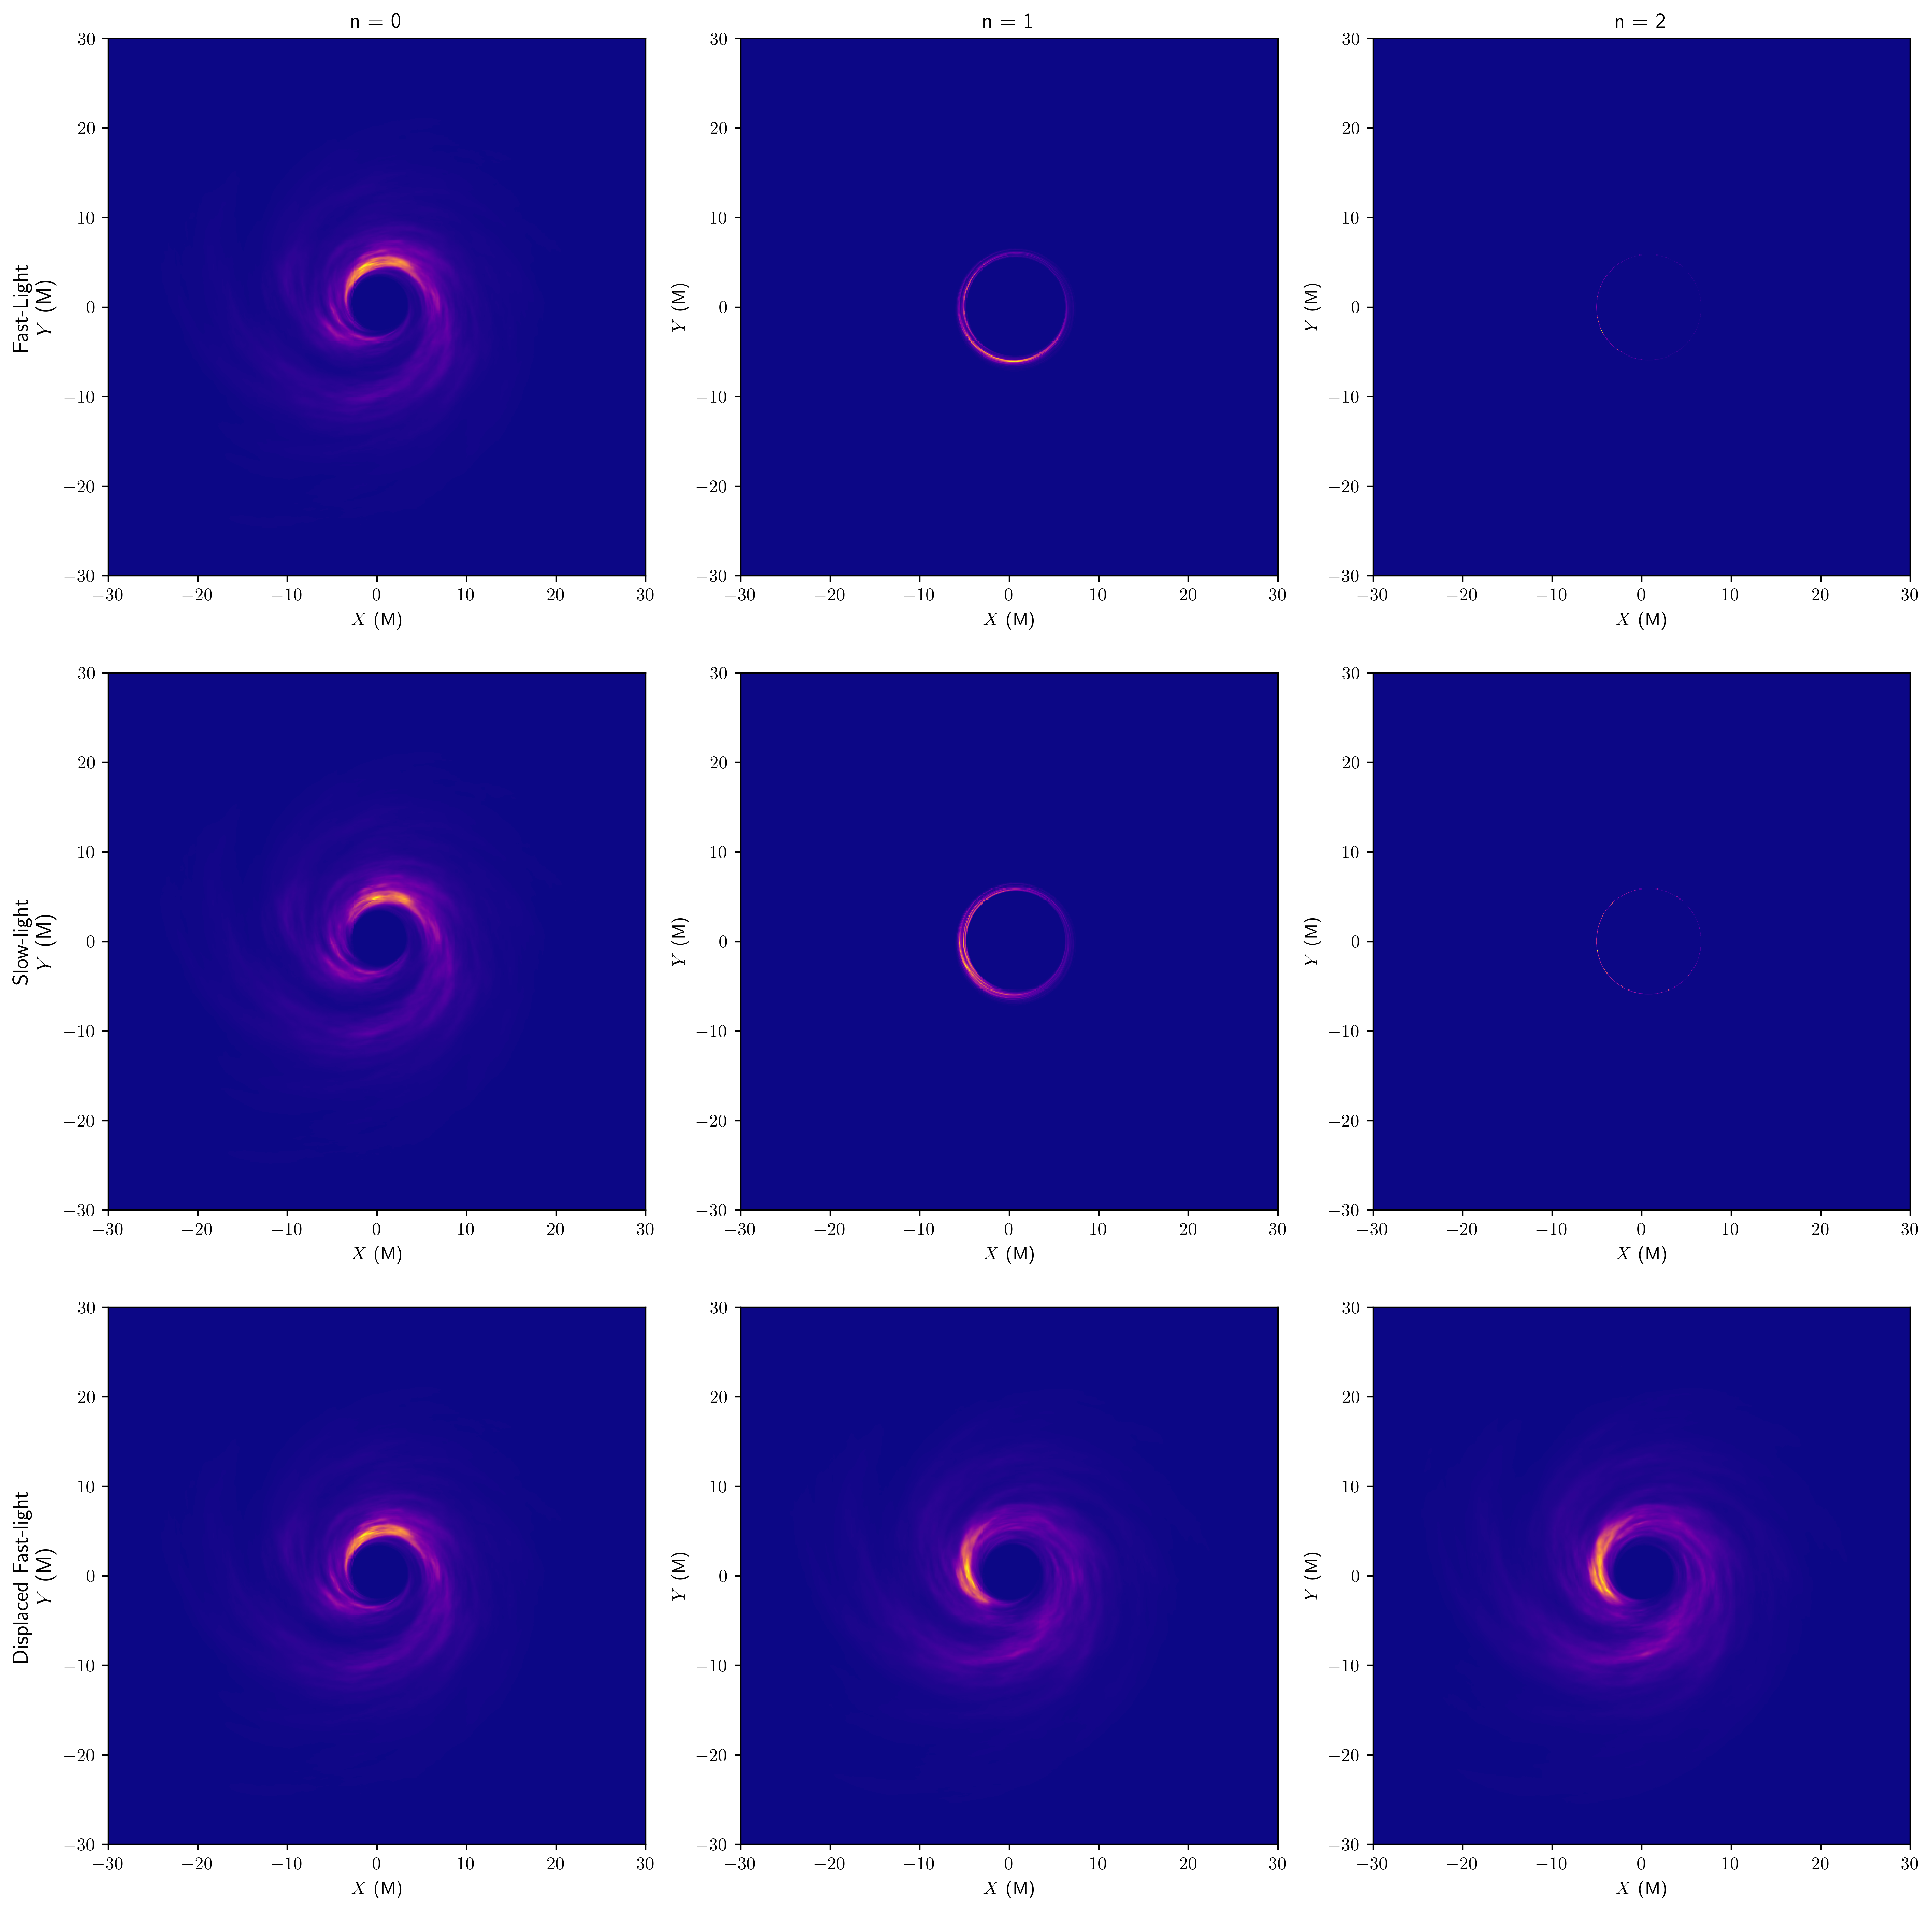

In [35]:
grupo1 = [I0, I1, I2]
grupo2 = [Is0, Is1, Is2]
grupo3 = [Ib0, Ib1*np.exp(gammap), Ib2*np.exp(2*gammap)]

# Crear una figura con 3 filas y 3 columnas
fig, axes = plt.subplots(3, 3, figsize=[15, 15], dpi=400)

# Títulos para las filas (opcional)
titulos_filas = ['Fast-Light', 'Slow-light', 'Displaced Fast-light']

# Títulos para las columnas (opcional)
titulos_columnas = ['n = 0', 'n = 1', 'n = 2']

# Mostrar los snapshots
for i, grupo in enumerate([grupo1, grupo2, grupo3]):
    for j, snapshot in enumerate(grupo):
        ax = axes[i, j]
        
        # Mostrar la imagen
        im = ax.imshow(snapshot, cmap="plasma", origin="lower", extent=[-30, 30, -30, 30])
        
        # Configurar cada subplot
        ax.set_facecolor('xkcd:black')
        ax.set_xlabel(r"$X$" + " " + "(M)")
        ax.set_ylabel(r"$Y$" + " " + "(M)")
        
        # Agregar títulos a las filas (lado izquierdo)
        if j == 0:
            ax.set_ylabel(titulos_filas[i] + "\n" + r"$Y$" + " " + "(M)", fontsize=12)
        
        # Agregar títulos a las columnas (parte superior)
        if i == 0:
            ax.set_title(titulos_columnas[j], fontsize=12)

# Ajustar el espaciado
plt.tight_layout()

# Mostrar la figura
plt.show()

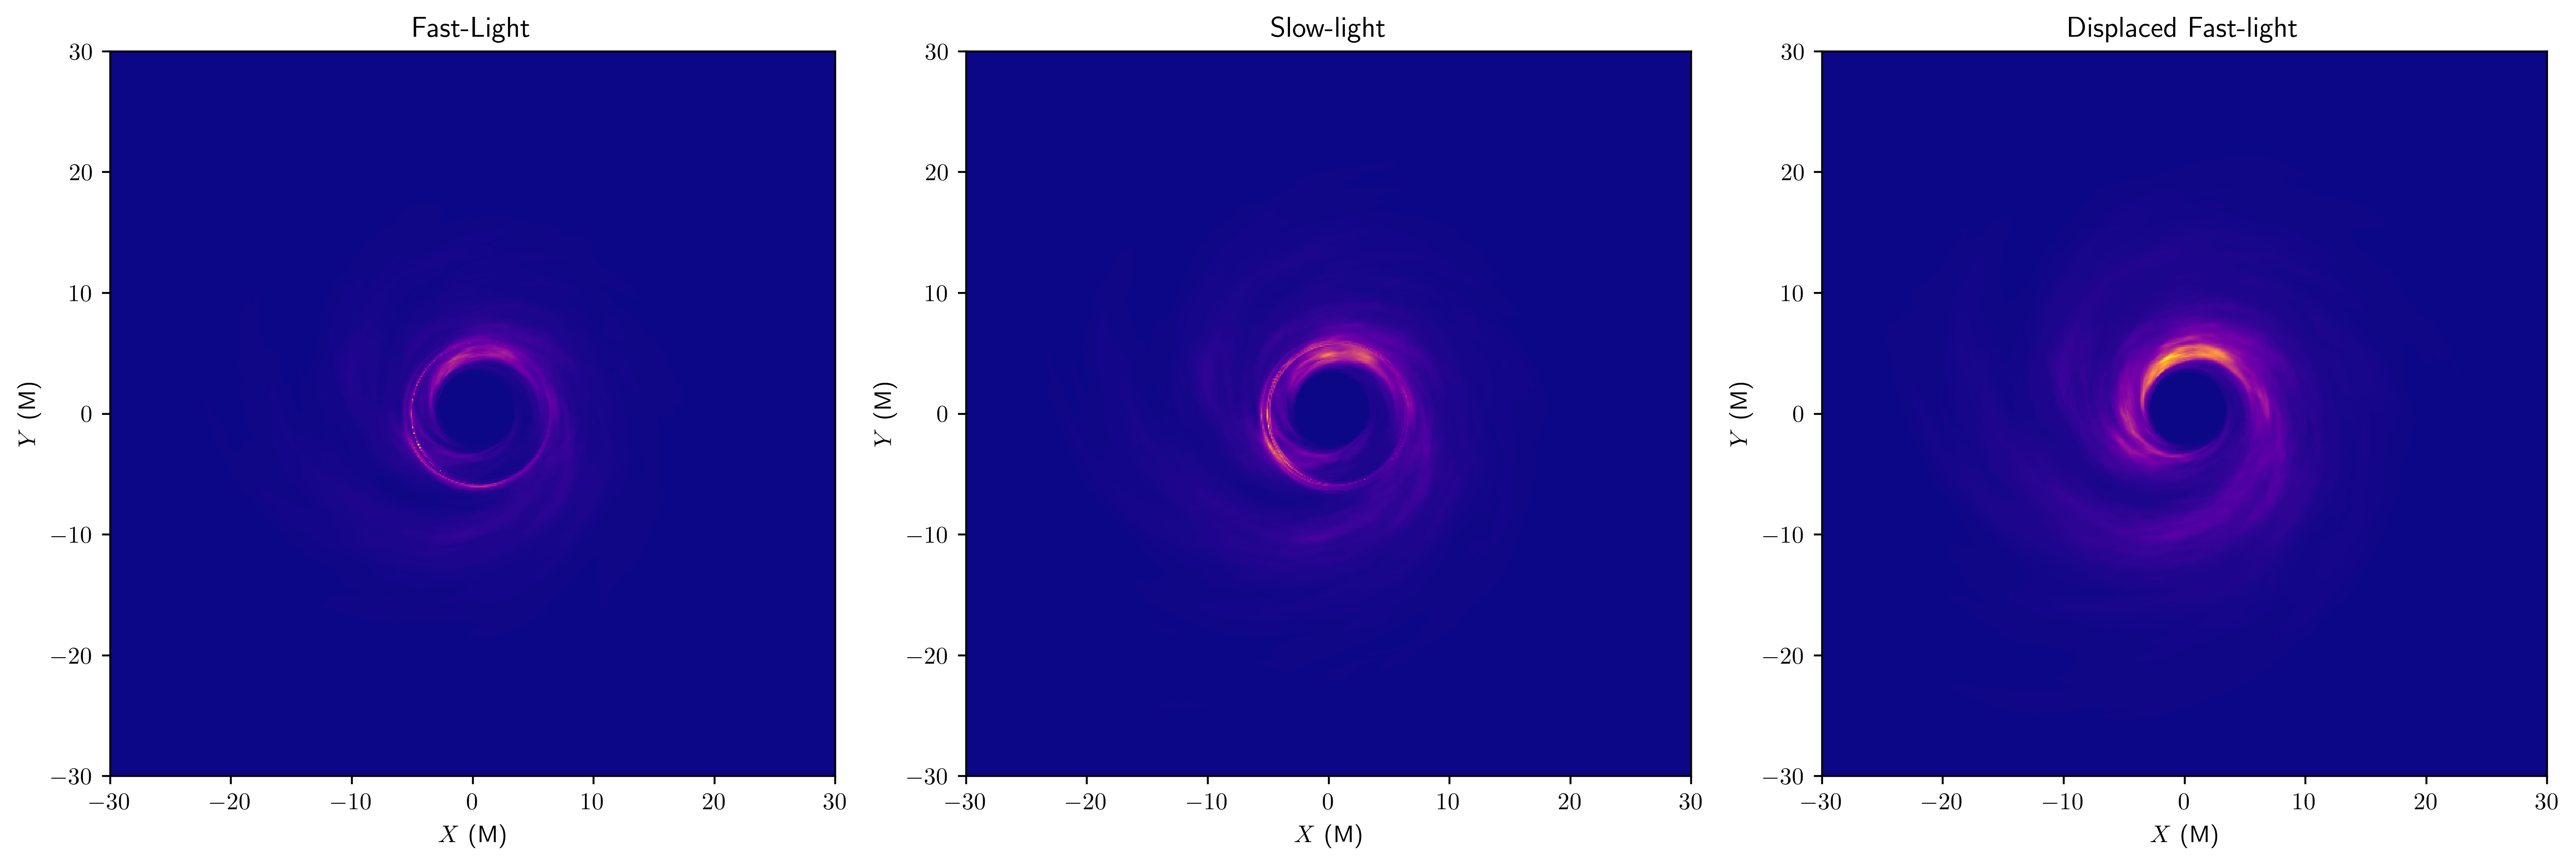

In [37]:
suma_original = I0 + I1 + I2
suma_suavizada = Is0 + Is1 + Is2
suma_fondo = Ib0 + Ib1*np.exp(gammap) + Ib2*np.exp(2*gammap)

# Crear una figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=[15, 5], dpi=400)

# Lista con las sumas y sus títulos
sumas = [suma_original, suma_suavizada, suma_fondo]
titulos = ['Fast-Light', 'Slow-light', 'Displaced Fast-light']

# Mostrar cada suma en un subplot
for i, (ax, suma, titulo) in enumerate(zip(axes, sumas, titulos)):
    # Mostrar la imagen
    im = ax.imshow(suma, cmap="plasma", origin="lower", extent=[-30, 30, -30, 30])
    
    # Configurar cada subplot
    ax.set_facecolor('xkcd:black')
    ax.set_xlabel(r"$X$" + " " + "(M)")
    ax.set_ylabel(r"$Y$" + " " + "(M)")
    ax.set_title(titulo, fontsize=12)
    
    # Opcional: agregar una barra de color
    # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()